In [ ]:
import sys
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
from mplsoccer import Pitch, VerticalPitch
from typing import Optional

sys.path.append(os.path.abspath("../"))
from soccer_one_twos_extractor.pipeline.pipe import MetricPipeline
from soccer_one_twos_extractor.constants.fields import F

In [27]:
data_folder_path = "../data/F24 La Liga 2023"
logos_folder_path = "../assets/La Liga 2023 logos"
fbref_csv_file = "fbref_playersdb.csv"

# Plotting helpers

In [3]:
def plot_team_one_twos(one_twos_df, team_name):
    team_df = one_twos_df[
        (one_twos_df["home_team_name"] == team_name)
        | (one_twos_df["away_team_name"] == team_name)
    ].copy()

    matches = team_df["match_name"].unique()

    for match in matches:
        match_df = team_df[team_df["match_name"] == match]

        if match_df["home_team_name"].iloc[0] == team_name:
            team_id = match_df["home_team_id"].iloc[0]
        else:
            team_id = match_df["away_team_id"].iloc[0]

        match_team_df = match_df[match_df["team_id"] == team_id]

        pitch = Pitch(
            pitch_type="custom",
            pitch_width=68,
            pitch_length=105,
            pitch_color="#17212d",
            line_color="white",
        )

        fig, ax = pitch.draw(figsize=(8, 8))

        for i, row in match_team_df.iterrows():
            # First pass (A → B)
            pitch.arrows(
                row["x_A"],
                row["y_A"],
                row["pass_end_x_A"],
                row["pass_end_y_A"],
                width=1.5,
                headwidth=5,
                color="cyan",
                ax=ax,
                label="First pass" if i == match_team_df.index[0] else "",
            )

            # Return pass (B → A)
            pitch.arrows(
                row["x_B"],
                row["y_B"],
                row["pass_end_x_B"],
                row["pass_end_y_B"],
                width=1.5,
                headwidth=5,
                color="lime",
                ax=ax,
                label="Return pass" if i == match_team_df.index[0] else "",
            )

            # Dashed lime line: carry (A's pass end → B's pass start)
            ax.plot(
                [row["pass_end_x_A"], row["x_B"]],
                [row["pass_end_y_A"], row["y_B"]],
                linestyle="--",
                color="lime",
                linewidth=1,
                alpha=0.7,
            )

            # Dashed cyan line: full progression (A's start → B's pass end)
            ax.plot(
                [row["x_A"], row["pass_end_x_B"]],
                [row["y_A"], row["pass_end_y_B"]],
                linestyle="--",
                color="cyan",
                linewidth=1,
                alpha=0.7,
            )

            # Minute label (from A's pass time)
            minute = int(row["time_seconds_A"] // 60)
            ax.text(
                row["x_A"],
                row["y_A"] + 1,
                f"{minute}′",
                fontsize=8,
                color="white",
                ha="center",
                va="bottom",
            )

        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), loc="upper left", fontsize=10)

        # Add score in title
        home_team = match_team_df["home_team_name"].iloc[0]
        away_team = match_team_df["away_team_name"].iloc[0]
        home_score = match_team_df["home_score"].iloc[0]
        away_score = match_team_df["away_score"].iloc[0]

        ax.set_title(
            f"{team_name} One-Twos: {home_team} {home_score}–{away_score} {away_team}",
            fontsize=14,
        )
        plt.show()

In [4]:
def plot_season_avg_one_twos(one_twos_df, logo_folder=None):
    import matplotlib.pyplot as plt
    from matplotlib.offsetbox import OffsetImage, AnnotationBbox
    from PIL import Image
    import os

    df = one_twos_df.copy()
    match_counts = (
        df.groupby([F.GAME_ID, F.TEAM_NAME]).size().reset_index(name="one_twos")
    )

    # Ensure all teams have a row for each of 38 games (zero if missing)
    teams = match_counts[F.TEAM_NAME].unique()
    games = match_counts[F.GAME_ID].unique()
    all_index = pd.MultiIndex.from_product(
        [games, teams], names=[F.GAME_ID, F.TEAM_NAME]
    )
    match_counts = (
        match_counts.set_index([F.GAME_ID, F.TEAM_NAME])
        .reindex(all_index, fill_value=0)
        .reset_index()
    )

    # Compute totals and std for each team over 38 games
    stats = (
        match_counts.groupby(F.TEAM_NAME)["one_twos"]
        .agg(total="sum", std="std")
        .assign(avg_one_twos=lambda x: x["total"] / 38)
        .sort_values("avg_one_twos")
        .reset_index()
        .rename(columns={"std": "std_one_twos"})
    )

    y = range(len(stats))
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.barh(
        y,
        stats["avg_one_twos"],
        xerr=stats["std_one_twos"],
        color="skyblue",
        edgecolor="black",
        height=0.65,
    )
    ax.set_yticks([])
    ax.set_xlabel("Average Progressive One-Twos per Game")
    ax.spines["left"].set_visible(False)

    x_logo, x_text = -1.7, -1.3
    ax.set_xlim(left=-1.7)

    for i, team in enumerate(stats[F.TEAM_NAME]):
        y_coord = i
        if logo_folder:
            logo_path = os.path.join(logo_folder, f"{team}.png")
            if os.path.exists(logo_path):
                img = Image.open(logo_path).resize((28, 28))
                ab = AnnotationBbox(
                    OffsetImage(img),
                    (x_logo, y_coord),
                    frameon=False,
                    box_alignment=(1, 0.5),
                )
                ax.add_artist(ab)
        ax.text(
            x_text, y_coord, team, va="center", ha="left", fontsize=10, color="#222"
        )

    ax.set_xticks([t for t in ax.get_xticks() if t >= 0])
    plt.tight_layout()
    plt.show()

In [5]:
def plot_one_twos_heatmap(df, teams_per_row=4):
    teams = df[F.TEAM_NAME].dropna().unique()
    n_teams = len(teams)
    n_rows = int(np.ceil(n_teams / teams_per_row))

    # 1) Create the figure and an outer GridSpec
    fig = plt.figure(figsize=(3.5 * teams_per_row * 2, 6 * n_rows))
    # use fig.add_gridspec for the outer layout
    outer = fig.add_gridspec(
        n_rows,
        teams_per_row,
        wspace=0.2,  # space BETWEEN different teams
        hspace=0.05,  # space BETWEEN rows of teams
    )

    pitch = VerticalPitch(
        pitch_type="custom",
        pitch_width=68,
        pitch_length=105,
        pitch_color="white",
        line_color="black",
        line_zorder=3,
        shade_middle=True,
        shade_alpha=0.1,
    )

    for idx, team in enumerate(teams):
        row = idx // teams_per_row
        col = idx % teams_per_row

        # 2) Derive a 1×2 “inner” GridSpec inside this single outer cell
        inner = outer[row, col].subgridspec(
            1,
            2,
            wspace=0.02,  # almost no gap BETWEEN Start & End
            width_ratios=[1, 1],
        )

        # Filter & clean your team data
        team_df = df[df[F.TEAM_NAME] == team].copy()
        for c in ["x_A", "y_A", "pass_end_x_B", "pass_end_y_B"]:
            team_df[c] = pd.to_numeric(team_df[c], errors="coerce")
        team_df = team_df.dropna(subset=["x_A", "y_A", "pass_end_x_B", "pass_end_y_B"])

        # 3) “Start” heatmap
        ax_start = fig.add_subplot(inner[0, 0])
        pitch.draw(ax=ax_start)
        if not team_df.empty:
            pitch.kdeplot(
                x=team_df["x_A"],
                y=team_df["y_A"],
                ax=ax_start,
                cmap="Blues",
                fill=True,
                thresh=0,
                levels=1000,
                zorder=1,
            )
        ax_start.set_title("Opening", fontsize=9)

        # 4) “End” heatmap
        ax_end = fig.add_subplot(inner[0, 1])
        pitch.draw(ax=ax_end)
        if not team_df.empty:
            pitch.kdeplot(
                x=team_df["pass_end_x_B"],
                y=team_df["pass_end_y_B"],
                ax=ax_end,
                cmap="Greens",
                fill=True,
                thresh=0,
                levels=1000,
                zorder=1,
            )
        ax_end.set_title("Closing", fontsize=9)

        # 5) Add the team name centered above the pair
        left = ax_start.get_position().x0
        right = ax_end.get_position().x1
        top = ax_start.get_position().y1
        fig.text(
            (left + right) / 2,
            top + 0.01,
            team,
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold",
        )

    plt.show()

In [ ]:
def plot_one_twos_per_90(
    common_minutes_df, one_twos_df, min_minutes=360, top_n=20, logo_folder=None
):
    pairs = {
        tuple(sorted([a, b]))
        for a, b in zip(one_twos_df["player_A_name"], one_twos_df["player_B_name"])
    }

    df = common_minutes_df[
        (common_minutes_df["common_minutes"] >= min_minutes)
        & (
            common_minutes_df.apply(
                lambda r: (r["player_1"], r["player_2"]) in pairs, axis=1
            )
        )
    ]

    a2b = (
        one_twos_df.groupby(["player_A_name", "player_B_name", "team_name"])
        .size()
        .reset_index(name="A2B")
    )

    b2a = (
        one_twos_df.groupby(["player_B_name", "player_A_name", "team_name"])
        .size()
        .reset_index(name="B2A")
        .rename(
            columns={"player_B_name": "player_A_name", "player_A_name": "player_B_name"}
        )
    )

    m = (
        df.merge(
            a2b,
            left_on=["player_1", "player_2", "team_name"],
            right_on=["player_A_name", "player_B_name", "team_name"],
            how="left",
        )
        .merge(
            b2a,
            left_on=["player_1", "player_2", "team_name"],
            right_on=["player_A_name", "player_B_name", "team_name"],
            how="left",
        )
        .fillna(0)
    )

    m["A2B_p90"] = m["A2B"] / m["common_minutes"] * 90
    m["B2A_p90"] = m["B2A"] / m["common_minutes"] * 90
    m["total_p90"] = m["A2B_p90"] + m["B2A_p90"]
    m = m.sort_values("total_p90", ascending=False).head(top_n)

    pos_all = get_pair_positions(one_twos_df)
    m = m.merge(
        pos_all,
        left_on=["player_1", "player_2", "team_name"],
        right_on=["player_A_name", "player_B_name", "team_name"],
        how="left",
    )

    mins = m["common_minutes"]
    norm = (mins - mins.min()) / (mins.max() - mins.min() + 1e-9)
    blues = [plt.cm.Blues(0.5 + 0.5 * n) for n in norm][::-1]
    greens = [plt.cm.Greens(0.5 + 0.5 * n) for n in norm][::-1]
    m = m.iloc[::-1].reset_index(drop=True)

    y = np.arange(len(m))
    fig, ax = plt.subplots(figsize=(15, max(7, len(m) * 0.43)))
    ax.barh(y, m["A2B_p90"], color=blues, label="player_1 opens")
    ax.barh(y, m["B2A_p90"], color=greens, left=m["A2B_p90"], label="player_2 opens")
    ax.set_yticks([])
    ax.set_xlabel("One-twos per 90 minutes")
    ax.set_title("One-twos per 90")
    ax.spines["left"].set_visible(False)

    for i, (team, a, b, pos_a, pos_b, cmin) in enumerate(
        zip(
            m["team_name"],
            m["player_1"],
            m["player_2"],
            m["player_A_position"],
            m["player_B_position"],
            m["common_minutes"],
        )
    ):
        pos1 = f" ({first_position(pos_a)})" if first_position(pos_a) else ""
        pos2 = f" ({first_position(pos_b)})" if first_position(pos_b) else ""
        a_name = f"{a}{pos1}"
        b_name = f"{b}{pos2}"
        label_text = f"{a_name} - {b_name}"
        ax.text(
            -0.8,
            i,
            label_text,
            va="center",
            ha="left",
            fontsize=9,
            color="black",
            clip_on=False,
        )

        if logo_folder:
            logo_path = os.path.join(logo_folder, f"{team}.png")
            if os.path.exists(logo_path):
                img = Image.open(logo_path).resize((22, 22))
                ab = AnnotationBbox(
                    OffsetImage(img), (-0.9, i), frameon=False, box_alignment=(1, 0.5)
                )
                ax.add_artist(ab)

    # Add total one-twos count next to the bars
    for i, total in enumerate((m["A2B"] + m["B2A"]).astype(int)):
        ax.text(
            m.loc[i, "total_p90"] + 0.2,
            i,
            f"{total} one-twos",
            va="center",
            ha="left",
            fontsize=8,
            color="gray",
        )

    ax.set_xlim(left=-1.3)
    ax.set_xticks([tick for tick in ax.get_xticks() if tick >= 0])

    plt.tight_layout(rect=[0, 0, 1, 0.88])
    plt.show()

In [ ]:
def plot_onetwos_chance_creation(
    df: pd.DataFrame,
    x_thresh: float = 70.0,
    logo_folder: Optional[str] = None,
):
    """Final-third one–twos per team: stacked % (B is key pass + next is key pass) with logos."""
    team_col = "team_name" if "team_name" in df.columns else "team_id"
    kp_b_col = "keypass_B" if "keypass_B" in df.columns else "KEY_PASS_B"
    kp_n_col = "keypass_next_B" if "keypass_next_B" in df.columns else "KEY_PASS_next_B"
    bar_height, label_decimals, x_max_pct = 0.60, 0, 100

    # compute per-team rates (fractions 0..1)
    ft = df.loc[df["x_A"] >= x_thresh].copy()

    def as_bool(s: pd.Series) -> pd.Series:
        """Return boolean Series: treat 1/'1'/True (any case/whitespace) as True."""
        return s.fillna(0).astype(str).str.strip().str.lower().isin({"1", "true"})

    ft["kpB"] = as_bool(ft[kp_b_col]).astype(int)
    ft["kpN"] = as_bool(ft[kp_n_col]).astype(int)
    stats = ft.groupby(team_col, as_index=False).agg(
        n_ft=("x_A", "size"), n_kpB=("kpB", "sum"), n_kpN=("kpN", "sum")
    )
    stats["pct_kpB"] = np.where(stats["n_ft"] > 0, stats["n_kpB"] / stats["n_ft"], 0.0)
    stats["pct_kpNext"] = np.where(
        stats["n_ft"] > 0, stats["n_kpN"] / stats["n_ft"], 0.0
    )
    stats["sort_key"] = stats["pct_kpB"] + stats["pct_kpNext"]
    stats = stats.sort_values("sort_key", ascending=True).reset_index(drop=True)

    # stacked widths (clip to 100%)
    w_b = stats["pct_kpB"].to_numpy(float)
    w_n_true = stats["pct_kpNext"].to_numpy(float)
    w_n = np.minimum(w_n_true, 1.0 - w_b)
    w_g = 1.0 - (w_b + w_n)
    y = np.arange(len(stats))

    # plot
    fig_h = max(4.5, 0.45 * len(stats) + 1.5)
    fig, ax = plt.subplots(figsize=(12, fig_h))
    ax.set_xlim(-0.22, x_max_pct / 100.0)  # ← add left margin so logos are visible
    margin = bar_height * 1.8
    ax.set_ylim(-margin, len(stats) - 1 + margin)
    ax.set_yticks([])

    col_b, col_n, col_g = "#1f77b4", "#6baed6", "#e0e0e0"
    ax.barh(
        y,
        w_b,
        left=0.0,
        height=bar_height,
        color=col_b,
        edgecolor="none",
        label="One two led to key pass",
    )
    ax.barh(
        y,
        w_n,
        left=w_b,
        height=bar_height,
        color=col_n,
        edgecolor="none",
        label="One two followed by key pass",
    )
    ax.barh(y, w_g, left=w_b + w_n, height=bar_height, color=col_g, edgecolor="none")

    # labels on blue segments only (0–100%)
    for i, (b, n_true) in enumerate(zip(w_b, w_n_true)):
        if b > 0.02:
            ax.text(
                min(b, ax.get_xlim()[1]) - 0.005,
                i,
                f"{b*100:.{label_decimals}f}%",
                va="center",
                ha="right",
                color="white",
                fontsize=9,
            )
        if n_true > 0.02:
            right_edge = w_b[i] + min(n_true, 1 - w_b[i])
            ax.text(
                min(right_edge, ax.get_xlim()[1]) - 0.005,
                i,
                f"{n_true*100:.{label_decimals}f}%",
                va="center",
                ha="right",
                color="white",
                fontsize=9,
            )

    # logos + names at left (now inside the negative margin)
    x_logo, x_text = -0.18, -0.16
    for i, name in enumerate(stats[team_col].astype(str)):
        if logo_folder:
            path = os.path.join(logo_folder, f"{name}.png")
            if os.path.exists(path):
                try:
                    img = Image.open(path)
                    ab = AnnotationBbox(
                        OffsetImage(img, zoom=0.08),
                        (x_logo, i),
                        frameon=False,
                        box_alignment=(1, 0.5),
                    )
                    ax.add_artist(ab)
                except Exception:
                    pass
        ax.text(x_text, i, name, va="center", ha="left", fontsize=10, color="#222")

    # x-axis 0–100%
    xticks = np.linspace(0, x_max_pct, 5)
    ax.set_xticks(xticks / 100.0)
    ax.set_xticklabels([f"{int(t)}%" for t in xticks])

    for s in ("left", "right", "top"):
        ax.spines[s].set_visible(False)
    ax.legend(loc="lower right", frameon=False)
    ax.set_title("Final-third one–twos chance creation rate", pad=12)
    plt.tight_layout()
    plt.show()

    return stats[
        [team_col, "n_ft", "n_kpB", "n_kpN", "pct_kpB", "pct_kpNext", "sort_key"]
    ]

In [ ]:
def pos_bucket(pos_str: str) -> str:
    if pd.isna(pos_str):
        return "Other"
    toks = [
        t.strip().upper().replace("-", "") for t in str(pos_str).split(",") if t.strip()
    ]
    # look through tokens in order of appearance
    for t in toks:
        if t in {"RB", "LB", "RWB", "LWB", "WB"}:
            return "Fullback"
        if t in {"LW", "RW", "WF"}:
            return "Winger"
        if t in {"DM", "CDM", "CM", "RCM", "LCM", "AM", "CAM"}:
            return "Central midfield"
        if t in {"ST", "CF", "FW"}:
            return "Forward"
    return "Other"


def plot_onetwos_scatter_player(
    prog_df: pd.DataFrame,
    players_df: pd.DataFrame,
    min_minutes: int = 900,
    label_thresh: float = 0.6,
) -> pd.DataFrame:
    """Scatter: opened P90 vs closed P90 (player-level), bucketed into 5 roles."""
    # minutes + canonical name + bucket
    mins = (
        players_df.assign(bucket=players_df["pos"].map(pos_bucket))
        .groupby("player_id", as_index=False)
        .agg(
            played_minutes=("played_minutes", "sum"),
            player=(
                "player",
                lambda s: s.dropna().mode().iat[0] if s.dropna().size else "Unknown",
            ),
            bucket=(
                "bucket",
                lambda s: s.dropna().mode().iat[0] if s.dropna().size else "Other",
            ),
        )
    )

    # counts opened/closed
    opened = (
        prog_df.groupby("player_id_A")
        .size()
        .rename("opened")
        .reset_index()
        .rename(columns={"player_id_A": "player_id"})
    )
    closed = (
        prog_df.groupby("player_id_B")
        .size()
        .rename("closed")
        .reset_index()
        .rename(columns={"player_id_B": "player_id"})
    )

    df = (
        mins.merge(opened, on="player_id", how="left")
        .merge(closed, on="player_id", how="left")
        .fillna({"opened": 0, "closed": 0})
    )

    # filter + per90
    df = df[df["played_minutes"] >= min_minutes].copy().reset_index(drop=True)
    df["opened_p90"] = 90.0 * df["opened"] / df["played_minutes"]
    df["closed_p90"] = 90.0 * df["closed"] / df["played_minutes"]

    # sizes aligned to index
    m = df["played_minutes"]
    sizes = 40 + 260 * (m - m.min()) / (m.max() - m.min() + 1e-9)

    # palette for the 5 buckets
    palette = {
        "Fullback": "#1f77b4",
        "Winger": "#e377c2",
        "Central midfield": "#ff7f0e",
        "Forward": "#d62728",
        "Other": "#7f7f7f",
    }

    # plot
    fig, ax = plt.subplots(figsize=(12, 9))
    for bucket, g in df.groupby("bucket"):
        ax.scatter(
            g["opened_p90"],
            g["closed_p90"],
            s=sizes.loc[g.index],
            c=palette[bucket],
            alpha=0.85,
            edgecolors="none",
            label=bucket,
        )

    # medians
    mx, my = df["opened_p90"].median(), df["closed_p90"].median()
    ax.axvline(mx, ls="--", lw=1)
    ax.axhline(my, ls="--", lw=1)

    # label only standouts (last name)
    standout = df[
        (df["opened_p90"] >= label_thresh) | (df["closed_p90"] >= label_thresh)
    ]
    if not standout.empty:
        x0, x1 = ax.get_xlim()
        y0, y1 = ax.get_ylim()
        dx, dy = 0.01 * (x1 - x0), 0.01 * (y1 - y0)
        last_names = standout["player"].astype(str).str.split().str[-1]
        for x, y, name in zip(
            standout["opened_p90"], standout["closed_p90"], last_names
        ):
            ax.text(x + dx, y + dy, name, fontsize=9)

    ax.legend(title="Role", frameon=False, loc="upper left", ncol=1)
    ax.set_xlabel("One–twos opened per 90")
    ax.set_ylabel("One–twos closed per 90")
    ax.grid(True, ls="--", lw=0.5, alpha=0.5)
    ax.set_title(f"One–twos: opened vs closed (min {min_minutes} minutes)")
    plt.tight_layout()
    plt.show()

    return df[
        [
            "player_id",
            "player",
            "bucket",
            "played_minutes",
            "opened",
            "closed",
            "opened_p90",
            "closed_p90",
        ]
    ]

# Metric Extraction

In [7]:
def get_duos_common_minutes(association_metric_df, players_data):
    """
    Compute total minutes two players (involved in one-twos) shared on the pitch.

    Parameters:
        association_metric_df: DataFrame with ['player_A_name', 'player_B_name'] for one-two events.
        players_df: DataFrame with player info per match, including on/off times.

    Returns:
        DataFrame with ['player_1', 'player_2', 'team_name', 'common_minutes'].
    """

    # Build unique, unordered pairs from one-two events
    one_two_pairs = {
        tuple(sorted([a, b]))
        for a, b in zip(
            association_metric_df["player_A_name"],
            association_metric_df["player_B_name"],
        )
    }

    # Convert player on/off times to seconds
    for col in ["player_on", "player_off"]:
        t = players_data[col].str.split(":", expand=True).astype(int)
        players_data[f"{col}_s"] = t[0] * 60 + t[1]

    # Merge players from the same match and team to find all potential pairs
    cm = players_data.merge(
        players_data, on=["game_id", "team_name"], suffixes=("_x", "_y")
    )

    # Keep only unique player combinations (no self-pairing, no duplicates)
    cm = cm[cm["player_id_x"] < cm["player_id_y"]]
    cm = cm.dropna(subset=["player_x", "player_y"])

    # Create a unique pair key (unordered)
    cm["pair"] = list(
        map(
            lambda a, b: tuple(sorted((str(a), str(b)))), cm["player_x"], cm["player_y"]
        )
    )

    # Calculate overlapping minutes on the pitch between player pairs
    cm["overlap"] = (
        np.minimum(cm["player_off_s_x"], cm["player_off_s_y"])
        - np.maximum(cm["player_on_s_x"], cm["player_on_s_y"])
    ).clip(lower=0) / 60

    # Filter to only include pairs involved in one-twos
    cm = cm[cm["pair"].isin(one_two_pairs)]

    # Aggregate total common minutes per pair and team
    result = (
        cm.groupby(["pair", "team_name"], as_index=False)["overlap"]
        .sum()
        .rename(columns={"overlap": "common_minutes"})
    )

    # Split pair tuple into two separate player columns
    result[["player_1", "player_2"]] = pd.DataFrame(
        result["pair"].tolist(), index=result.index
    )
    result["common_minutes"] = result["common_minutes"].round(2)

    return result[["player_1", "player_2", "team_name", "common_minutes"]]


def get_pair_positions(one_twos_df):
    pos1 = one_twos_df[
        [
            "player_A_name",
            "player_B_name",
            "team_name",
            "player_A_position",
            "player_B_position",
        ]
    ].drop_duplicates()
    pos2 = one_twos_df[
        [
            "player_B_name",
            "player_A_name",
            "team_name",
            "player_B_position",
            "player_A_position",
        ]
    ].drop_duplicates()
    pos2.columns = pos1.columns
    return pd.concat([pos1, pos2]).drop_duplicates(
        subset=["player_A_name", "player_B_name", "team_name"]
    )


def first_position(pos):
    if isinstance(pos, str):
        return pos.split(",")[0].strip()
    return ""


def merge_one_twos_with_player_names(
    one_twos_df: pd.DataFrame, players_df: pd.DataFrame
) -> pd.DataFrame:
    """
    Merge one-twos event data with player names based on player IDs.

    Parameters:
        one_twos_df (pd.DataFrame): DataFrame containing one-twos with player_A and player_B IDs.
        players_df (pd.DataFrame): DataFrame containing player ID to name mappings per match/team.
        fields: Module or object containing constants like GAME_ID, TEAM_ID, PLAYER_ID.

    Returns:
        pd.DataFrame: Enriched one_twos_df with player_A_name and player_B_name.
    """
    merged = one_twos_df.merge(
        players_df[[F.GAME_ID, F.TEAM_ID, F.PLAYER_ID, "player", "pos"]].rename(
            columns={
                F.PLAYER_ID: f"{F.PLAYER_ID}_A",
                "player": "player_A_name",
                "pos": "player_A_position",
            }
        ),
        on=[F.GAME_ID, F.TEAM_ID, f"{F.PLAYER_ID}_A"],
        how="left",
    ).merge(
        players_df[[F.GAME_ID, F.TEAM_ID, F.PLAYER_ID, "player", "pos"]].rename(
            columns={
                F.PLAYER_ID: f"{F.PLAYER_ID}_B",
                "player": "player_B_name",
                "pos": "player_B_position",
            }
        ),
        on=[F.GAME_ID, F.TEAM_ID, f"{F.PLAYER_ID}_B"],
        how="left",
    )
    return merged

In [8]:
_pipe = MetricPipeline(
    data_folder=data_folder_path, external_player_file=fbref_csv_file, n_jobs=8
)

(
    events_df,
    players_df,
    progressive_one_twos_df,
) = _pipe.parallel_run()

Parsing matches: 100%|██████████| 380/380 [00:41<00:00,  9.06it/s]


In [68]:
# Merge progressive one twos with player names data
progressive_one_twos_df_ = merge_one_twos_with_player_names(
    progressive_one_twos_df, players_df
)

# Get one twos pairs common minutes
onetwos_pairs_df = get_duos_common_minutes(progressive_one_twos_df_, players_df)

In [ ]:
# def one_two_kp_rate_by_team(df, x_thresh=70):
#     group_cols = ["team_id"] + (["team_name"] if "team_name" in df.columns else [])
#     tmp = df.assign(
#         is_kp=df["keypass_B"].astype(str).eq("1"),
#         in_zone=df["x_A"] >= x_thresh,
#         hit=lambda x: x["is_kp"] & x["in_zone"],
#     )
#     return (
#         tmp.groupby(group_cols, as_index=False)
#         .agg(count=("hit", "sum"), denom=("in_zone", "sum"))
#         .assign(pct=lambda x: (x["count"] / x["denom"]).fillna(0))
#         .sort_values(["pct", "count"], ascending=[False, False])
#     )


# def one_two_nextkp_rate_by_team(df, x_thresh=70):
#     group_cols = ["team_id"] + (["team_name"] if "team_name" in df.columns else [])
#     tmp = df.assign(
#         is_kp=df["keypass_next_B"].astype(str).eq("1"),
#         in_zone=df["x_A"] >= x_thresh,
#         hit=lambda x: x["is_kp"] & x["in_zone"],
#     )
#     return (
#         tmp.groupby(group_cols, as_index=False)
#         .agg(count=("hit", "sum"), denom=("in_zone", "sum"))
#         .assign(pct=lambda x: (x["count"] / x["denom"]).fillna(0))
#         .sort_values(["pct", "count"], ascending=[False, False])
#     )


# def passes_kp_rate_by_team(df, x_thresh=70):
#     """Per-team: passes in final third, key passes there, and %."""
#     group_cols = ["team_id"] + (["team_name"] if "team_name" in df.columns else [])
#     tmp = df.loc[(df["event_name"] == "Pass")].assign(
#         in_ft=lambda x: x["x"] >= x_thresh,
#         is_kp=lambda x: x["keypass"].astype(str).eq("1"),
#         kp_in_ft=lambda x: x["in_ft"] & x["is_kp"],
#     )
#     return (
#         tmp.groupby(group_cols, as_index=False)
#         .agg(passes_ft=("in_ft", "sum"), keypasses_ft=("kp_in_ft", "sum"))
#         .assign(pct=lambda t: (t["keypasses_ft"] / t["passes_ft"]).fillna(0))
#         .sort_values(["pct", "keypasses_ft"], ascending=[False, False])
#     )


# by_team = one_two_kp_rate_by_team(progressive_one_twos_df_, x_thresh=70)
# by_team_next_kp = one_two_nextkp_rate_by_team(progressive_one_twos_df_, x_thresh=70)
# by_team_ft = passes_kp_rate_by_team(events_df, x_thresh=70)
# by_team_next_kp

,team_id,team_name,count,denom,pct
5,176,Celta de Vigo,10,75,0.133333
10,184,Rayo Vallecano,10,79,0.126582
18,450,Osasuna,7,61,0.114754
0,1450,Getafe,4,36,0.111111
3,174,Athletic Club,8,86,0.093023
11,185,Real Betis,7,79,0.088608
6,177,Espanyol,3,35,0.085714
9,181,Mallorca,3,38,0.078947
14,191,Valencia CF,6,78,0.076923
1,1564,Almería,3,46,0.065217


# LALIGA 2022 2023 Progressive One twos Analysis

### One twos preview

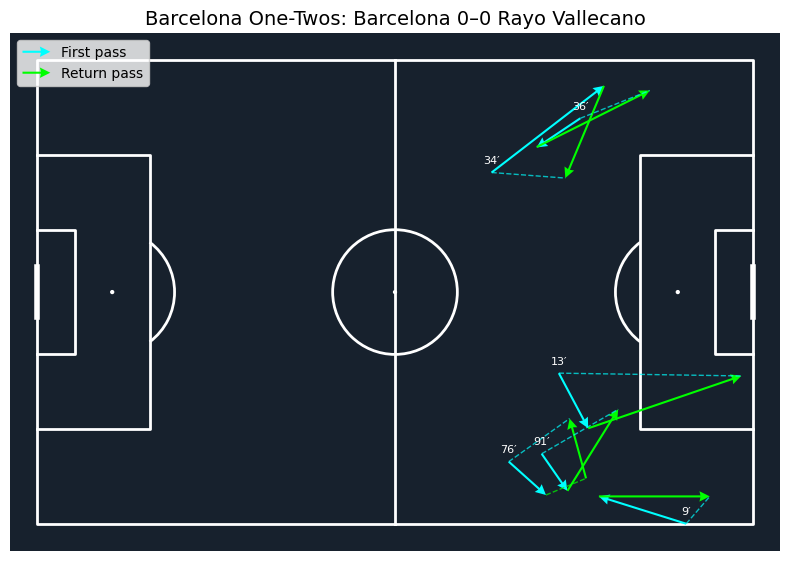

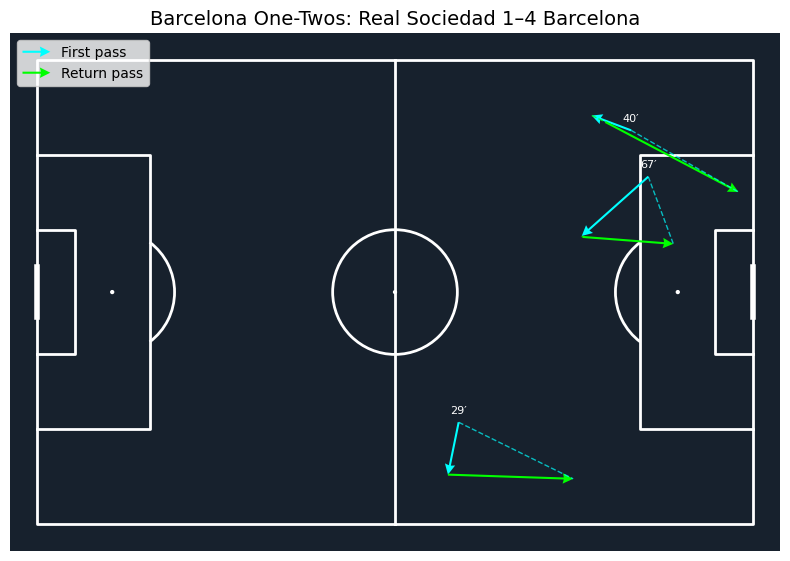

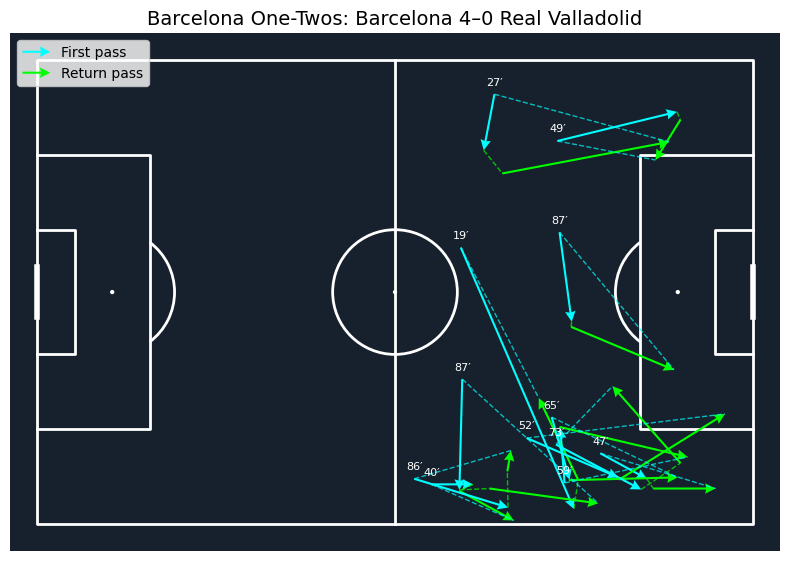

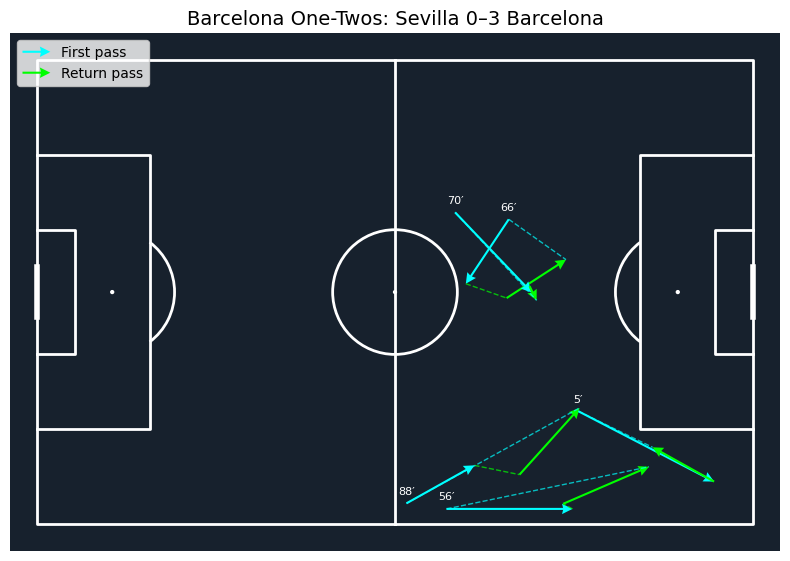

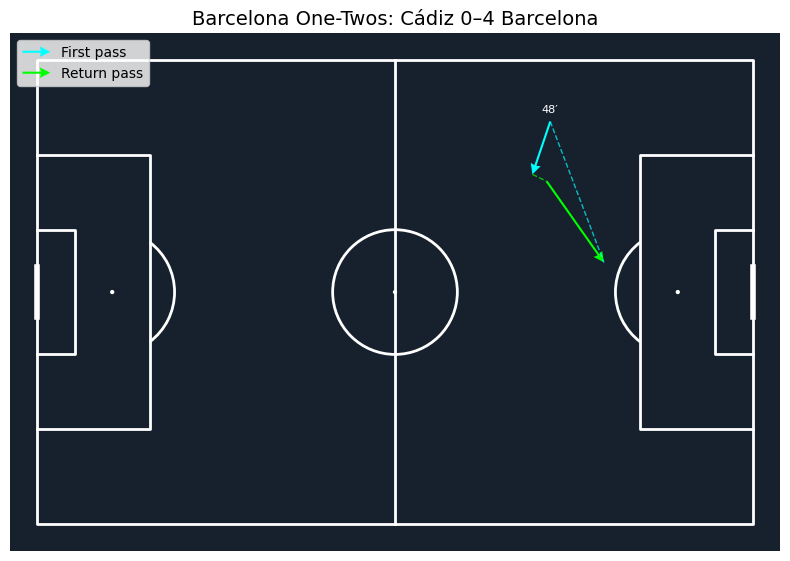

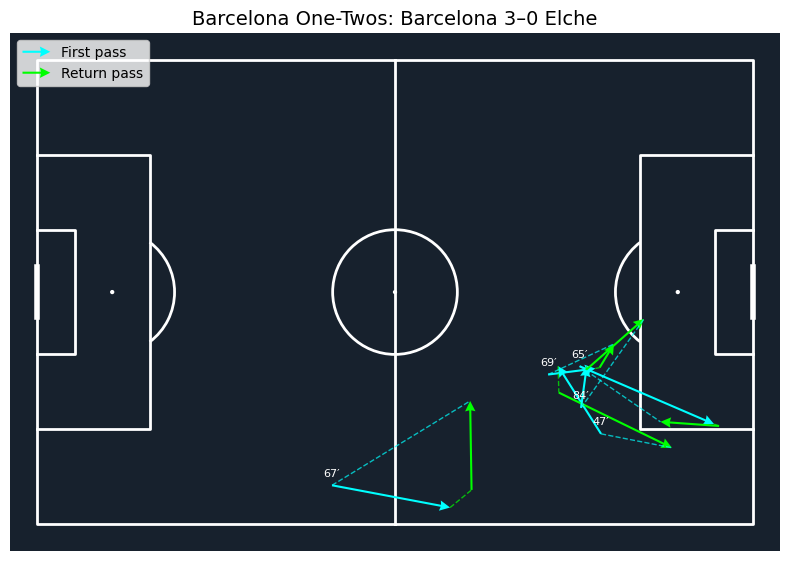

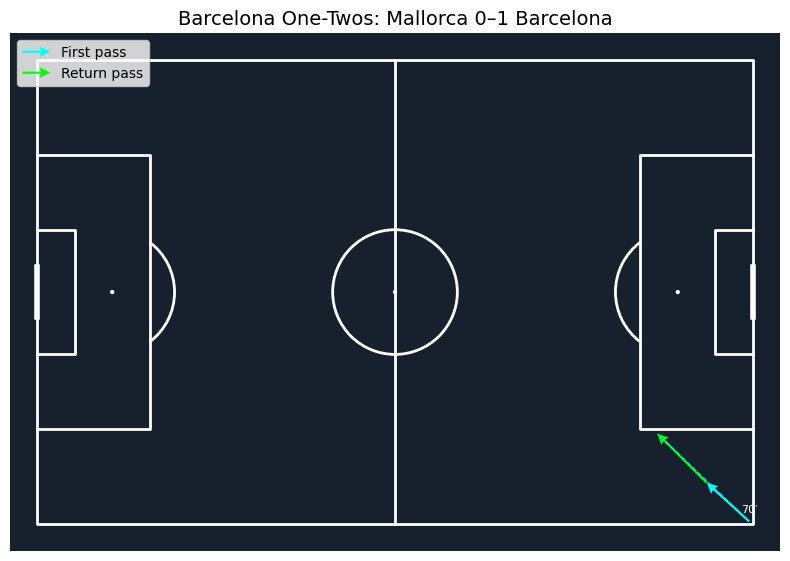

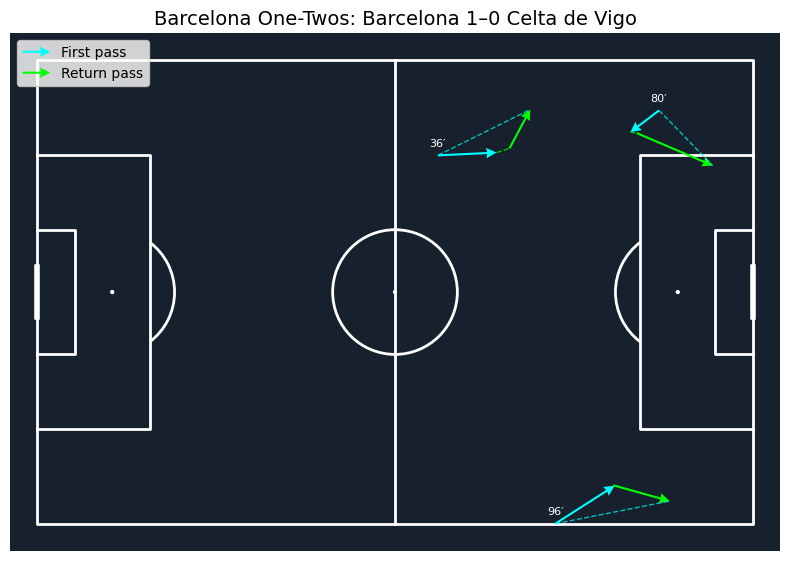

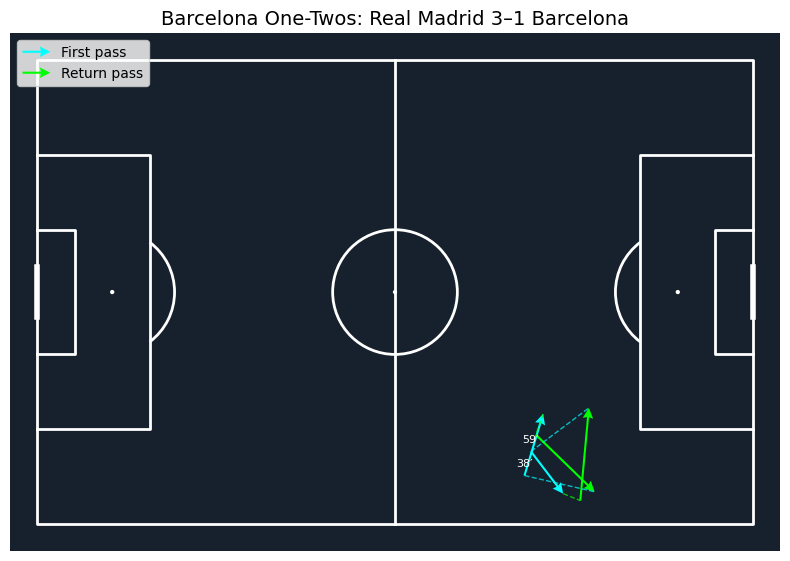

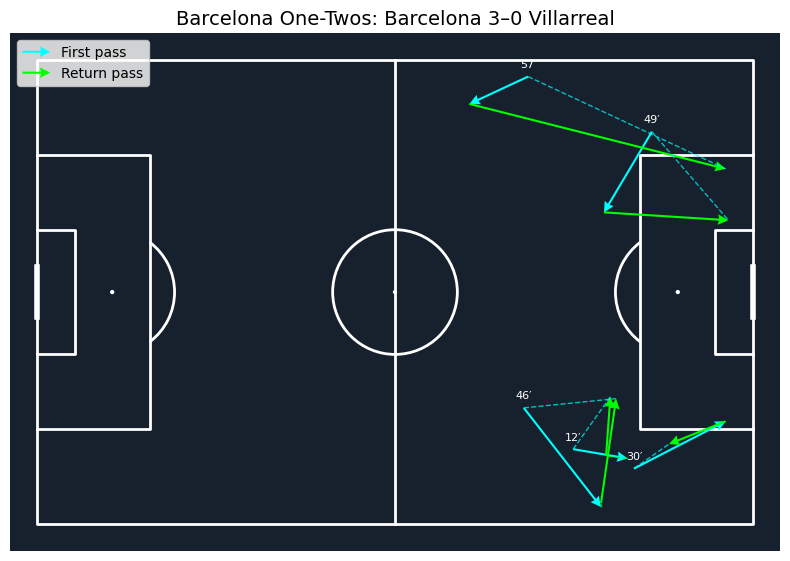

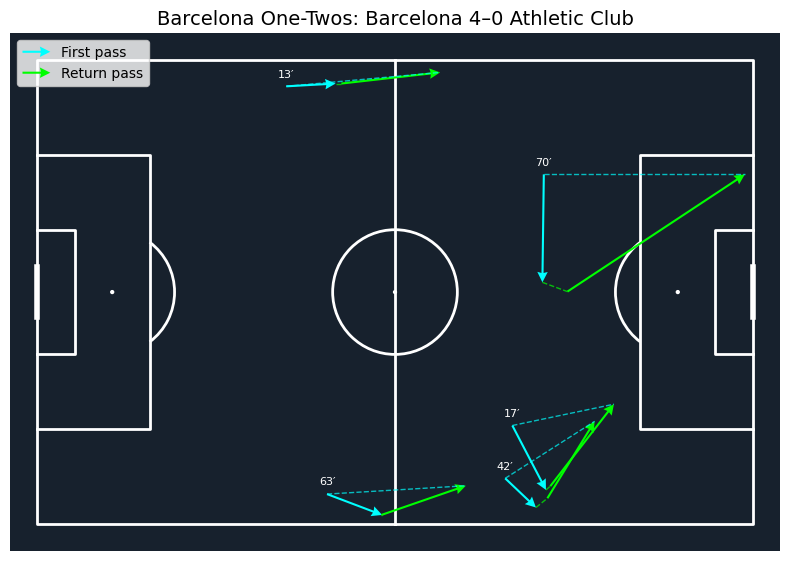

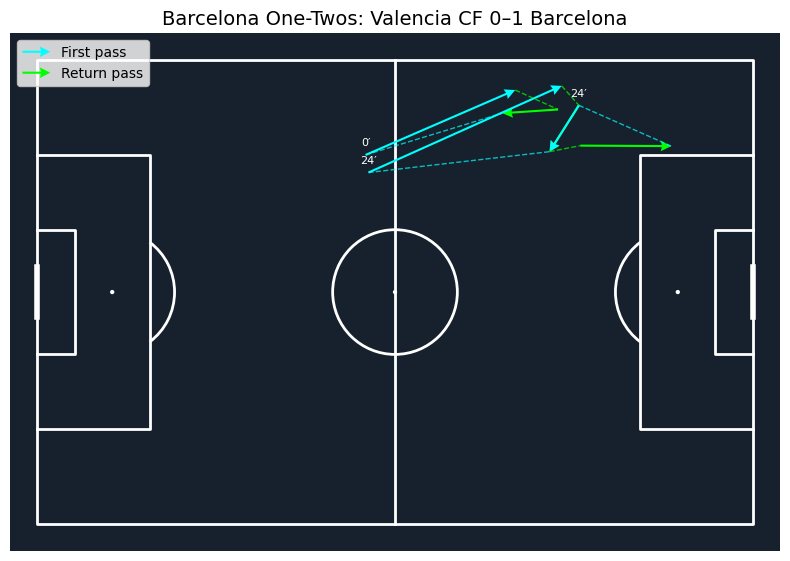

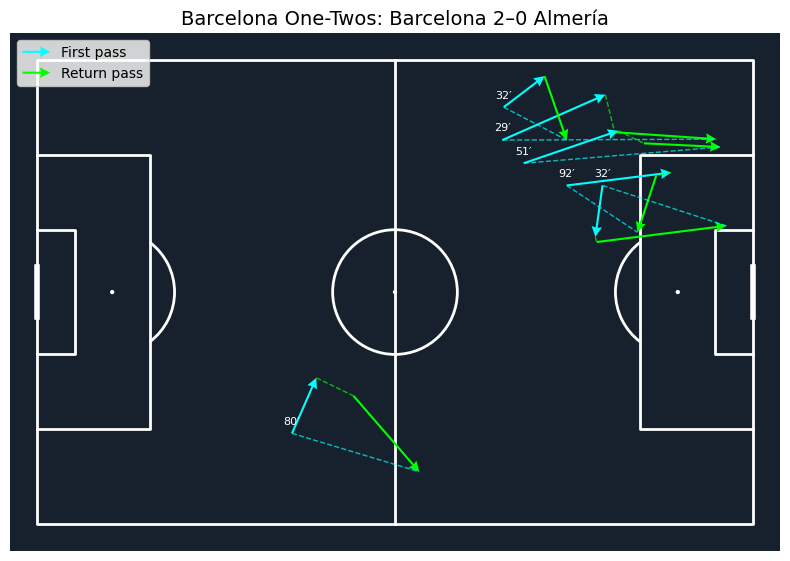

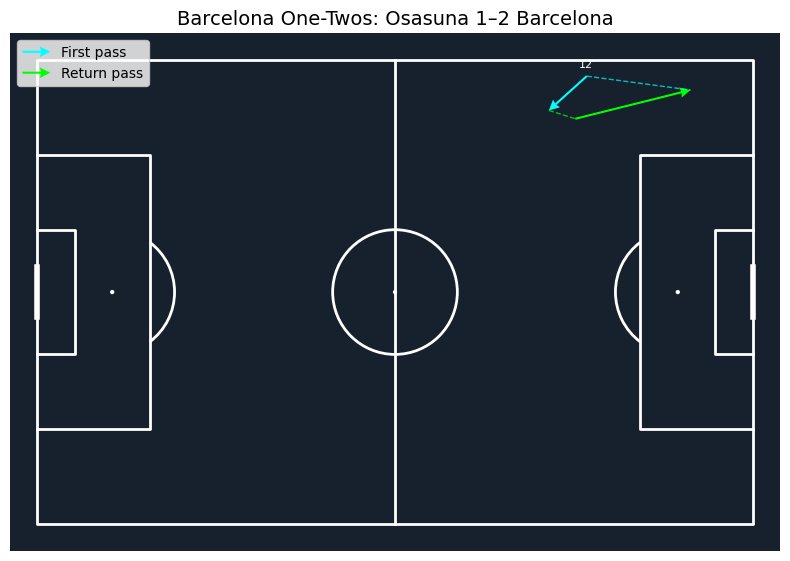

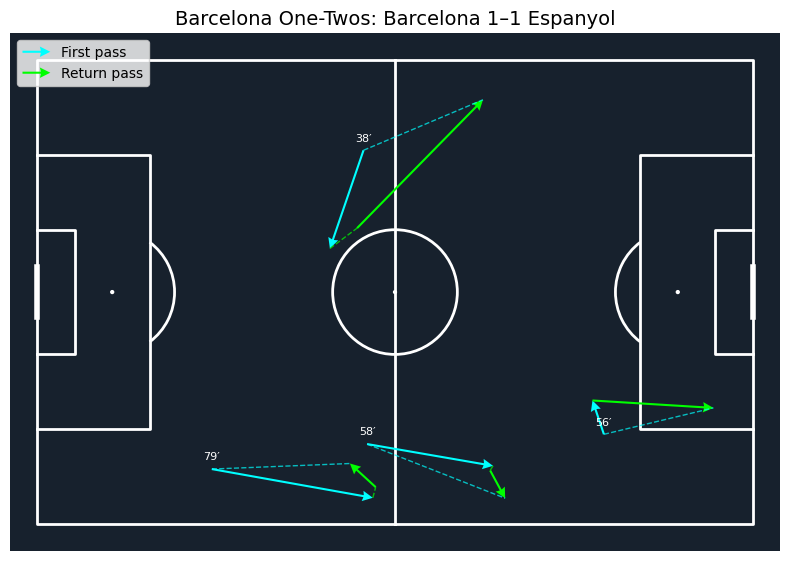

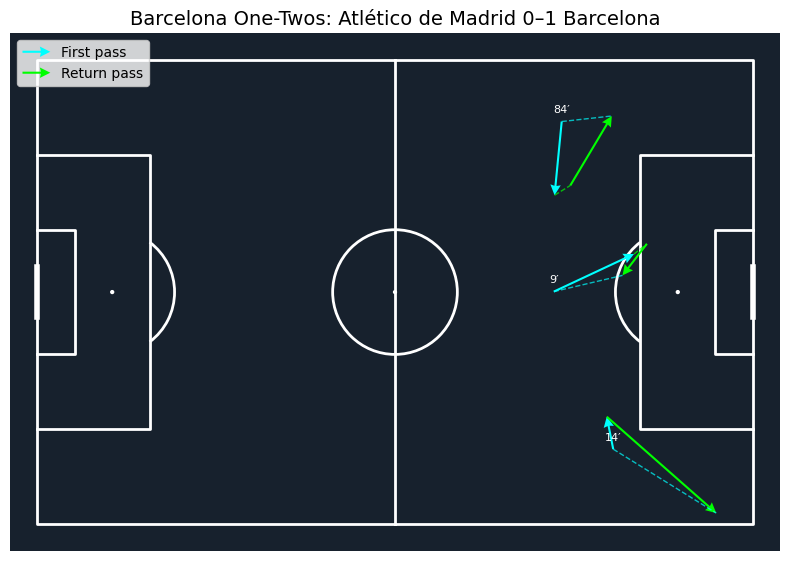

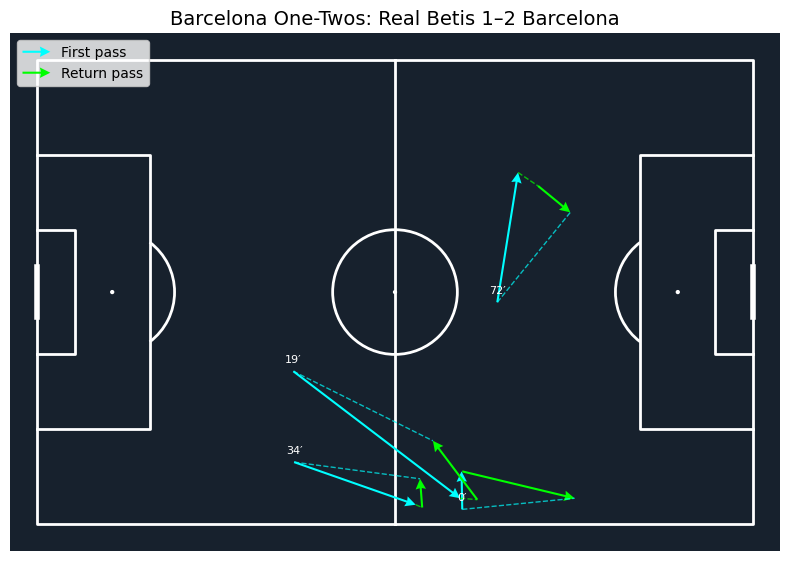

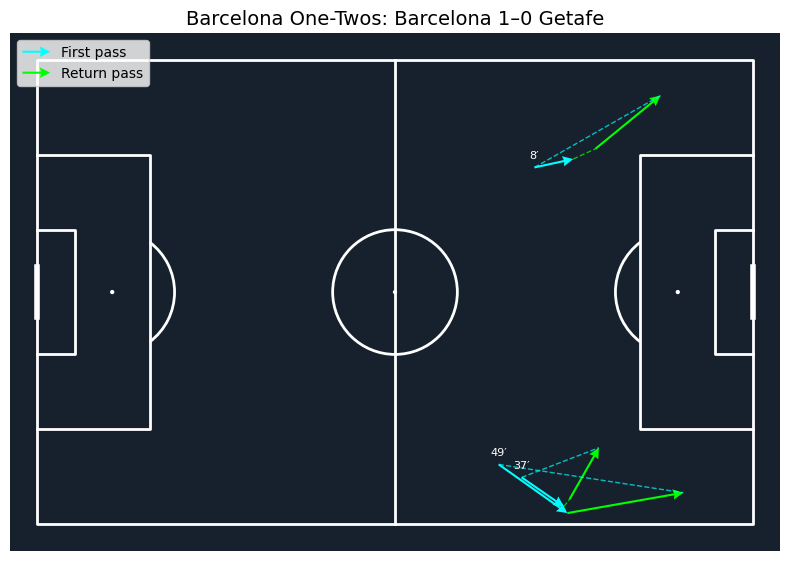

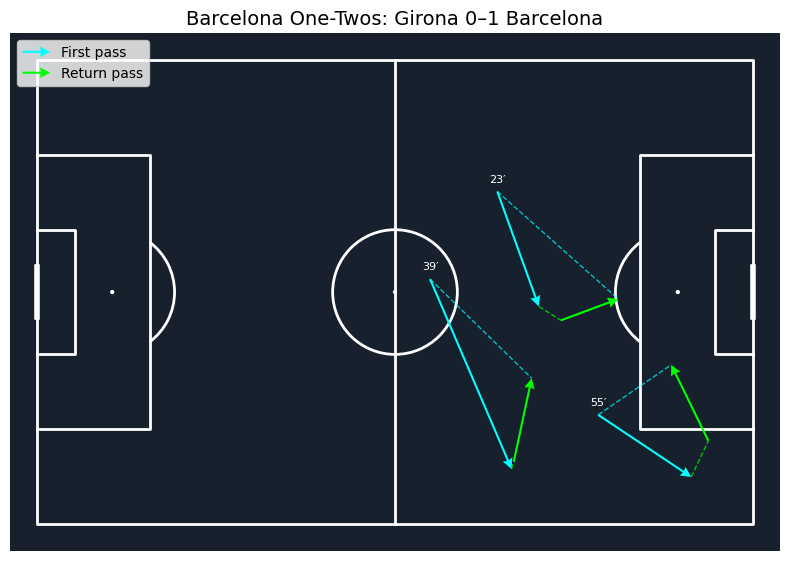

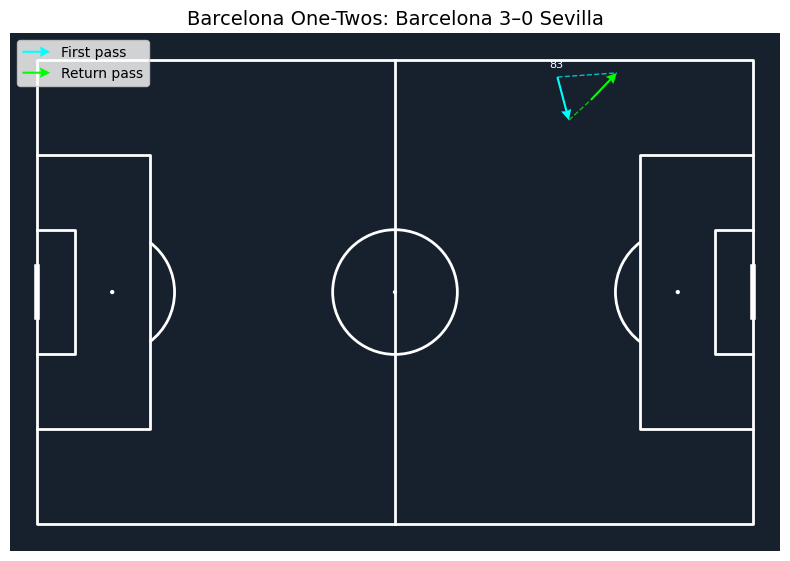

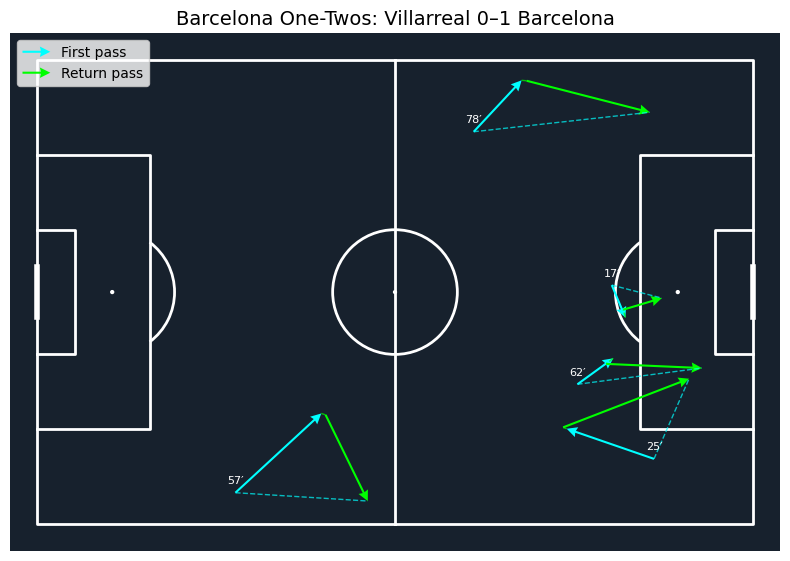

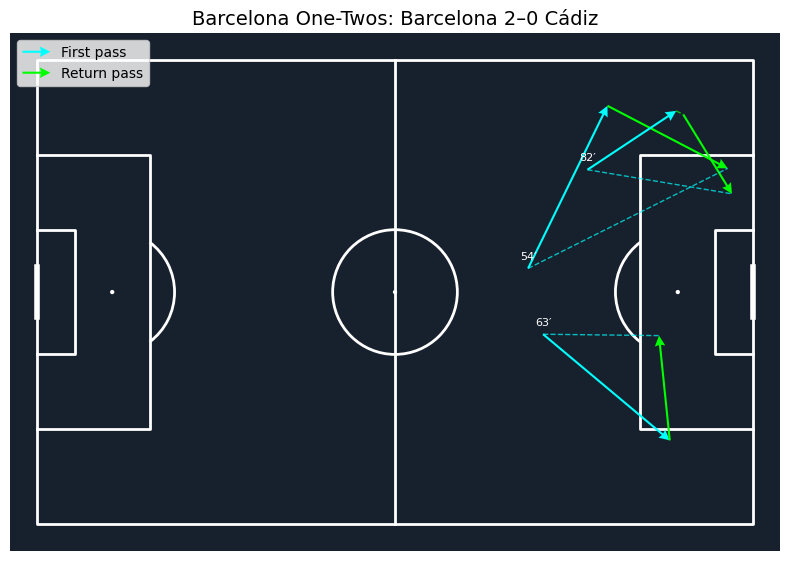

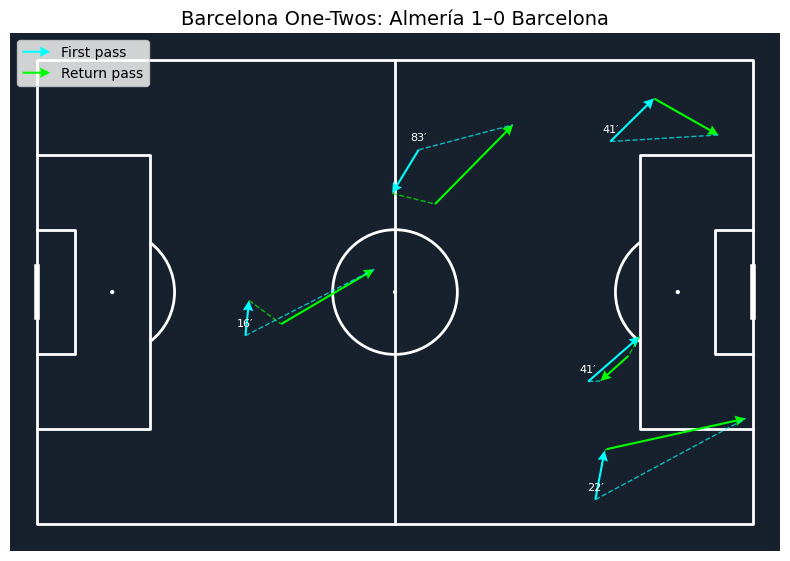

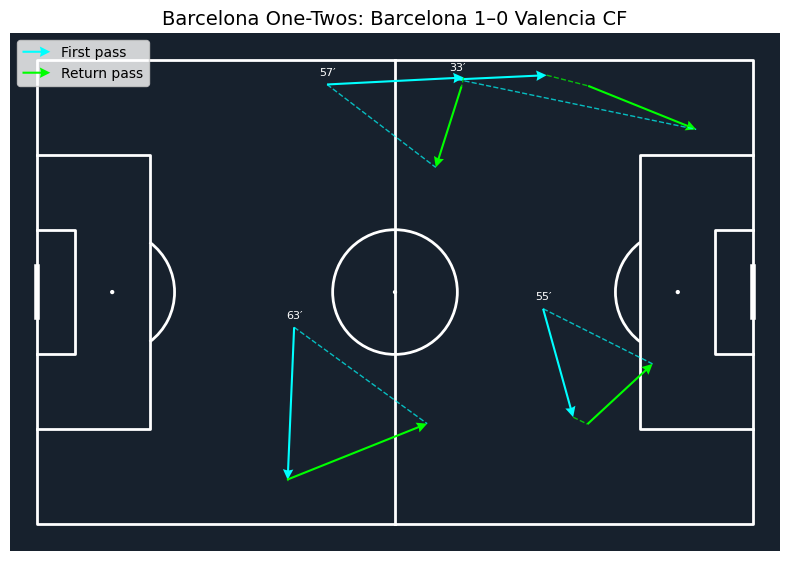

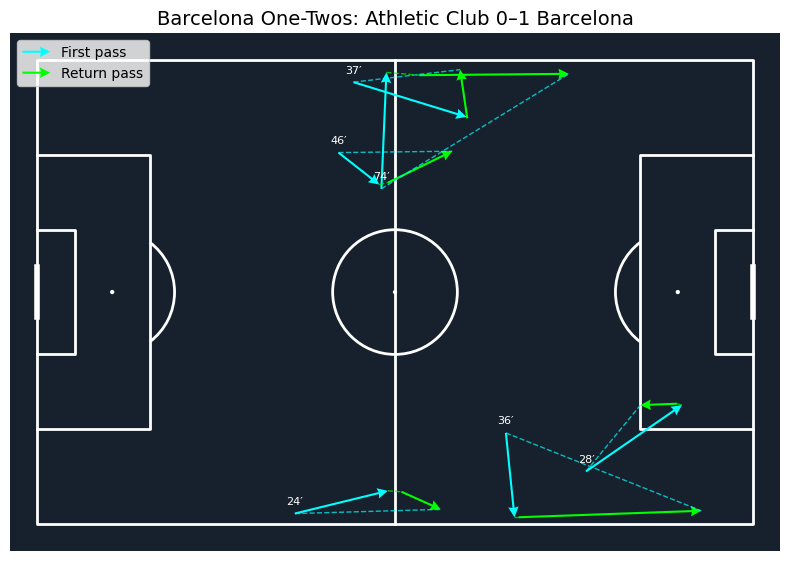

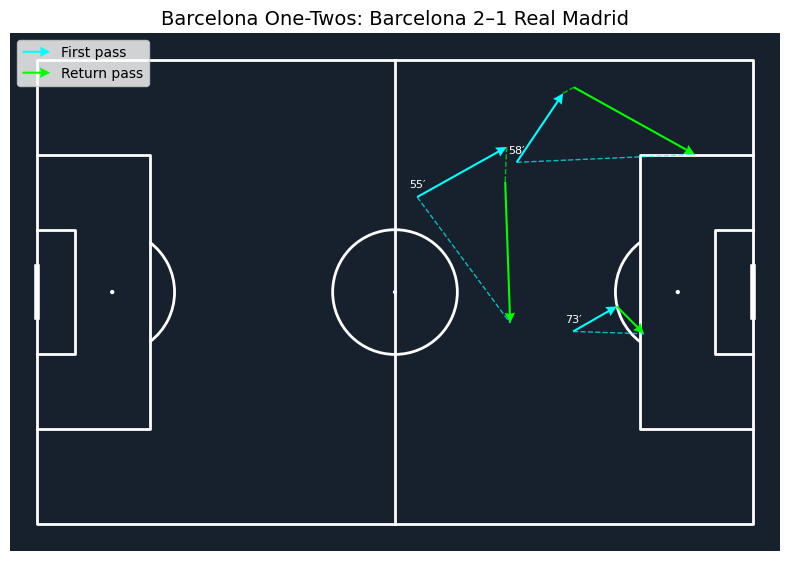

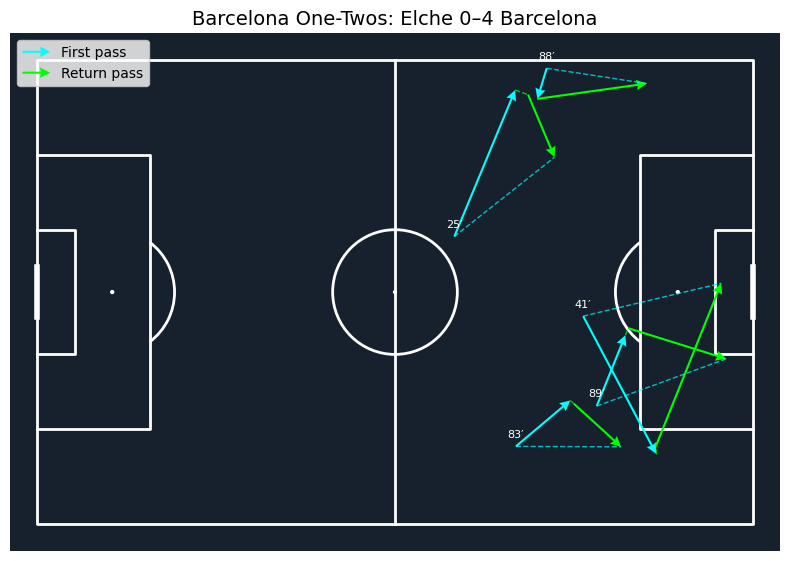

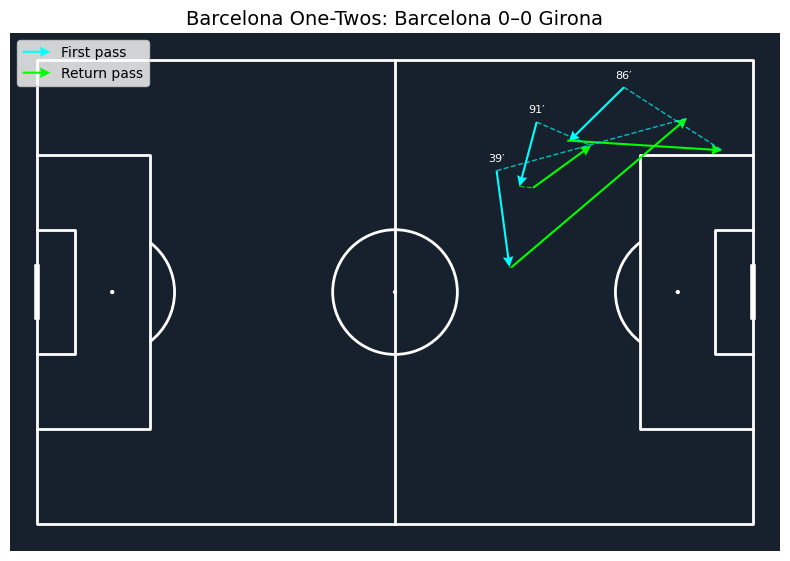

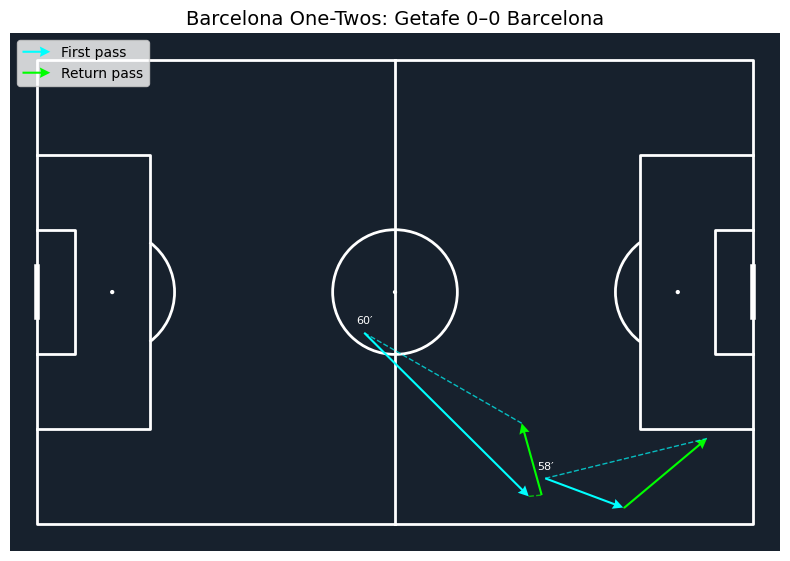

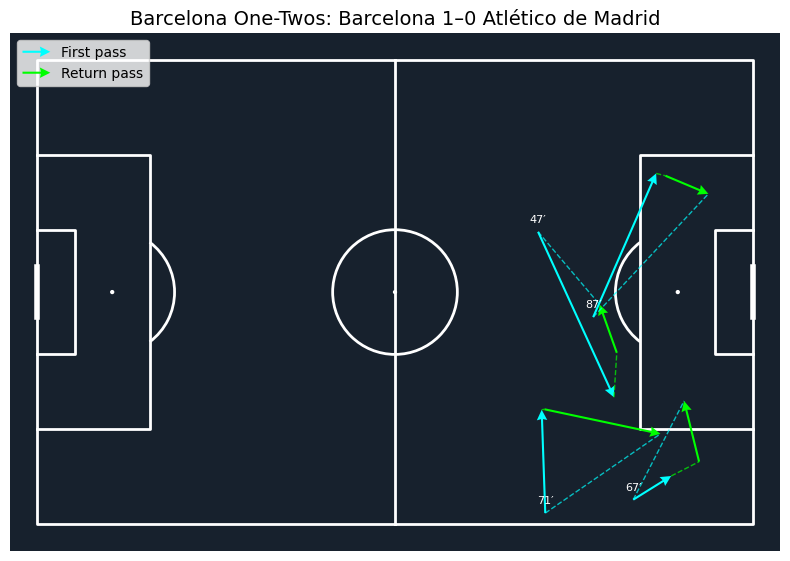

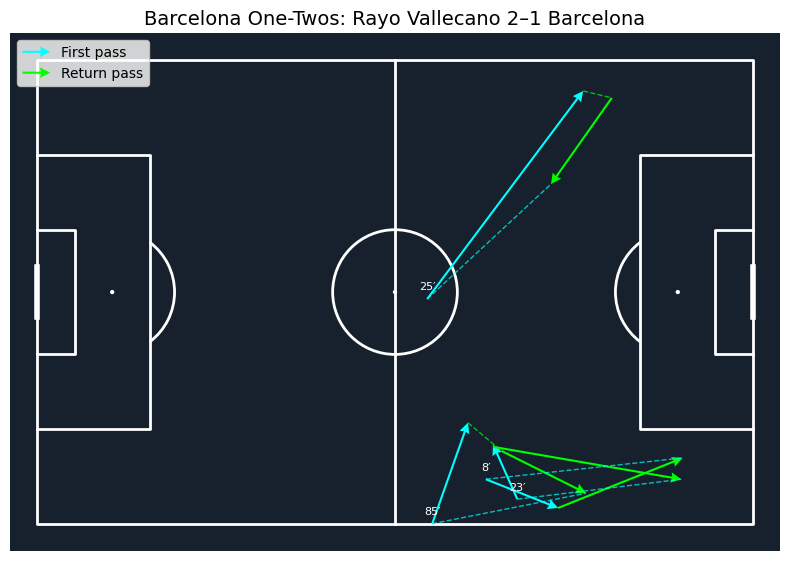

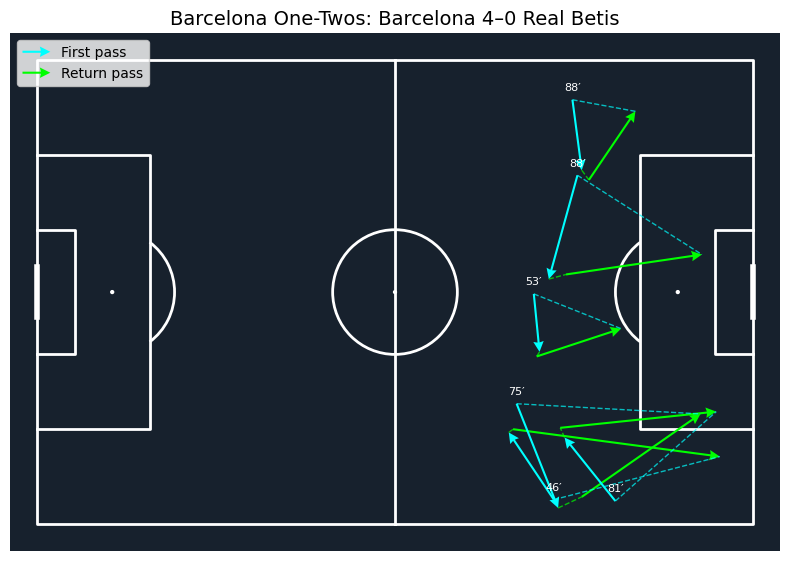

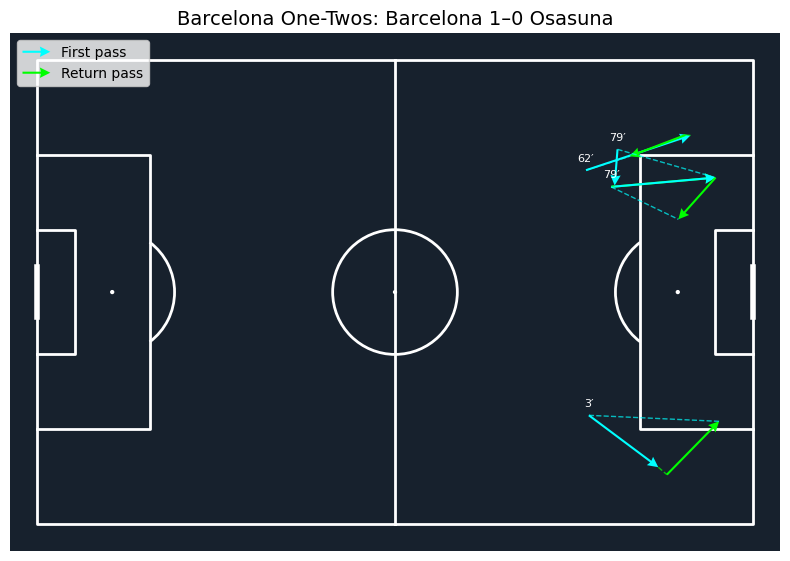

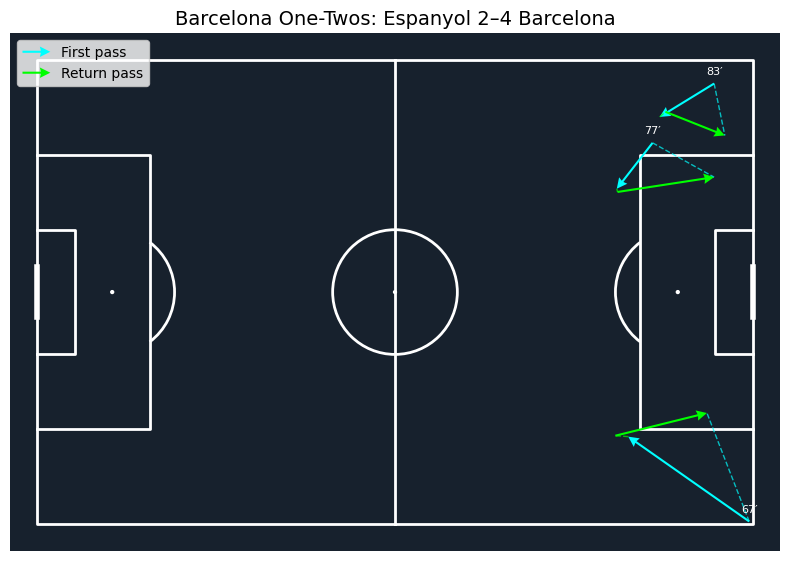

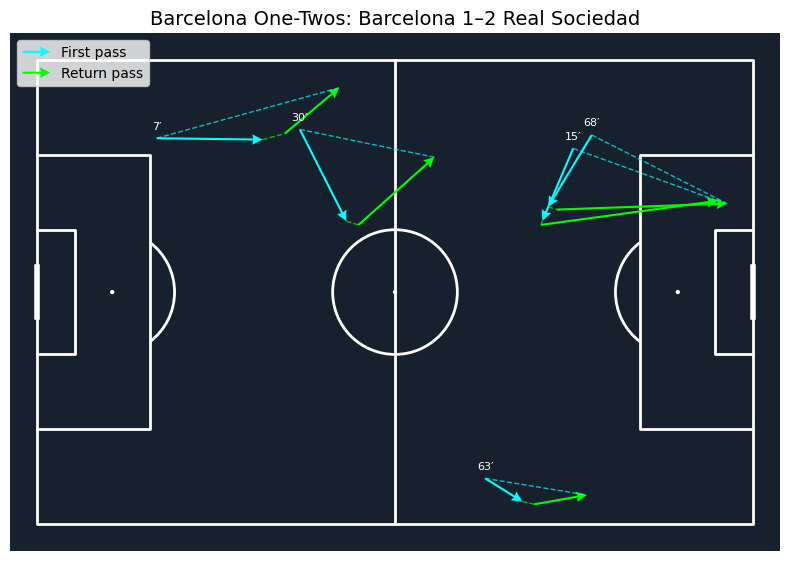

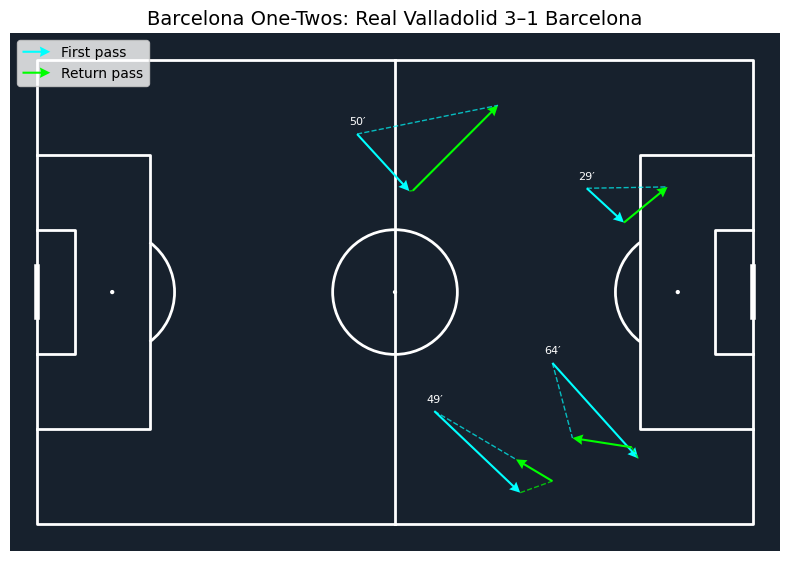

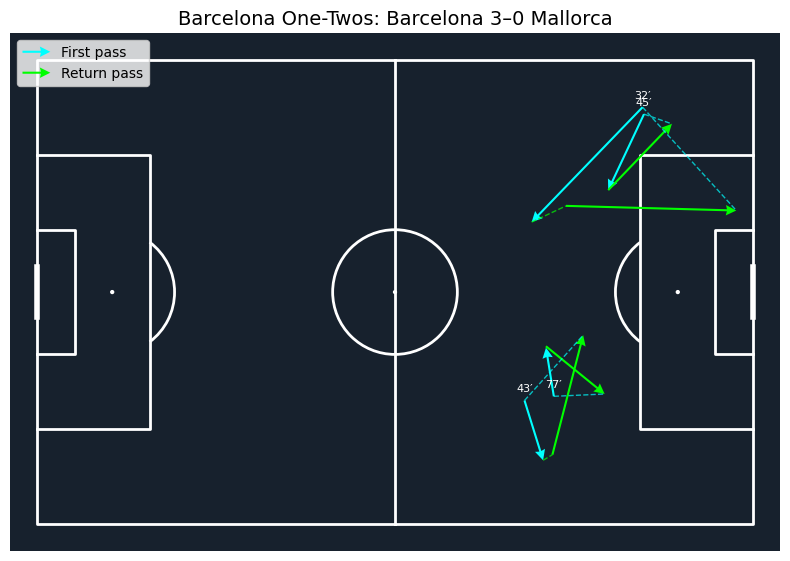

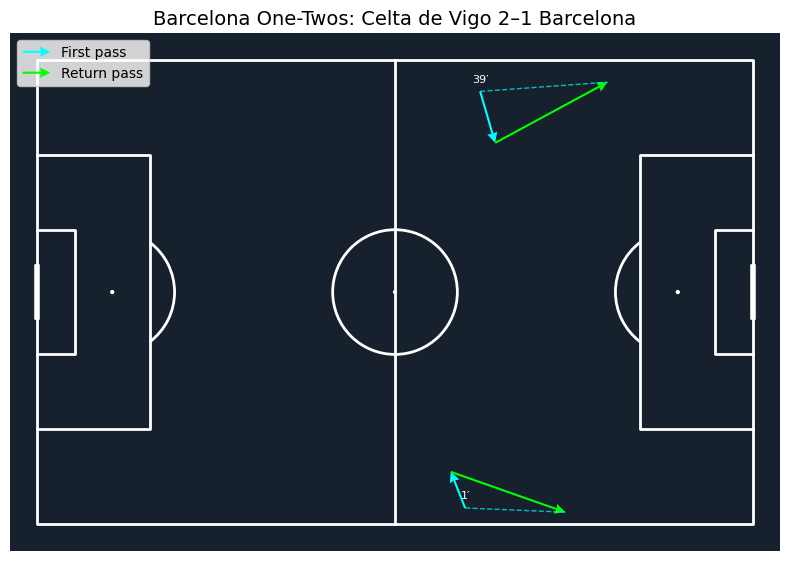

In [ ]:
plot_team_one_twos(progressive_one_twos_df_, "Barcelona")

### One twos rate (team level)

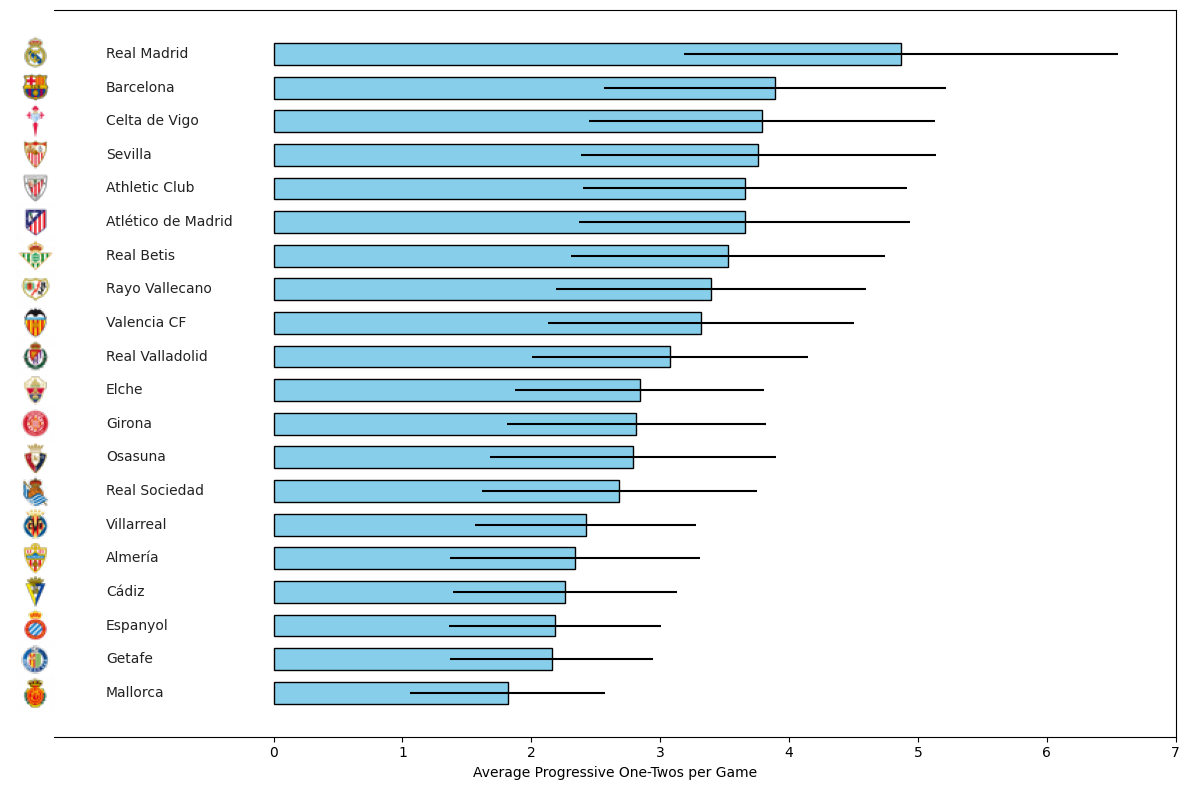

In [28]:
plot_season_avg_one_twos(progressive_one_twos_df, logos_folder_path)

### One twos spatial distribution

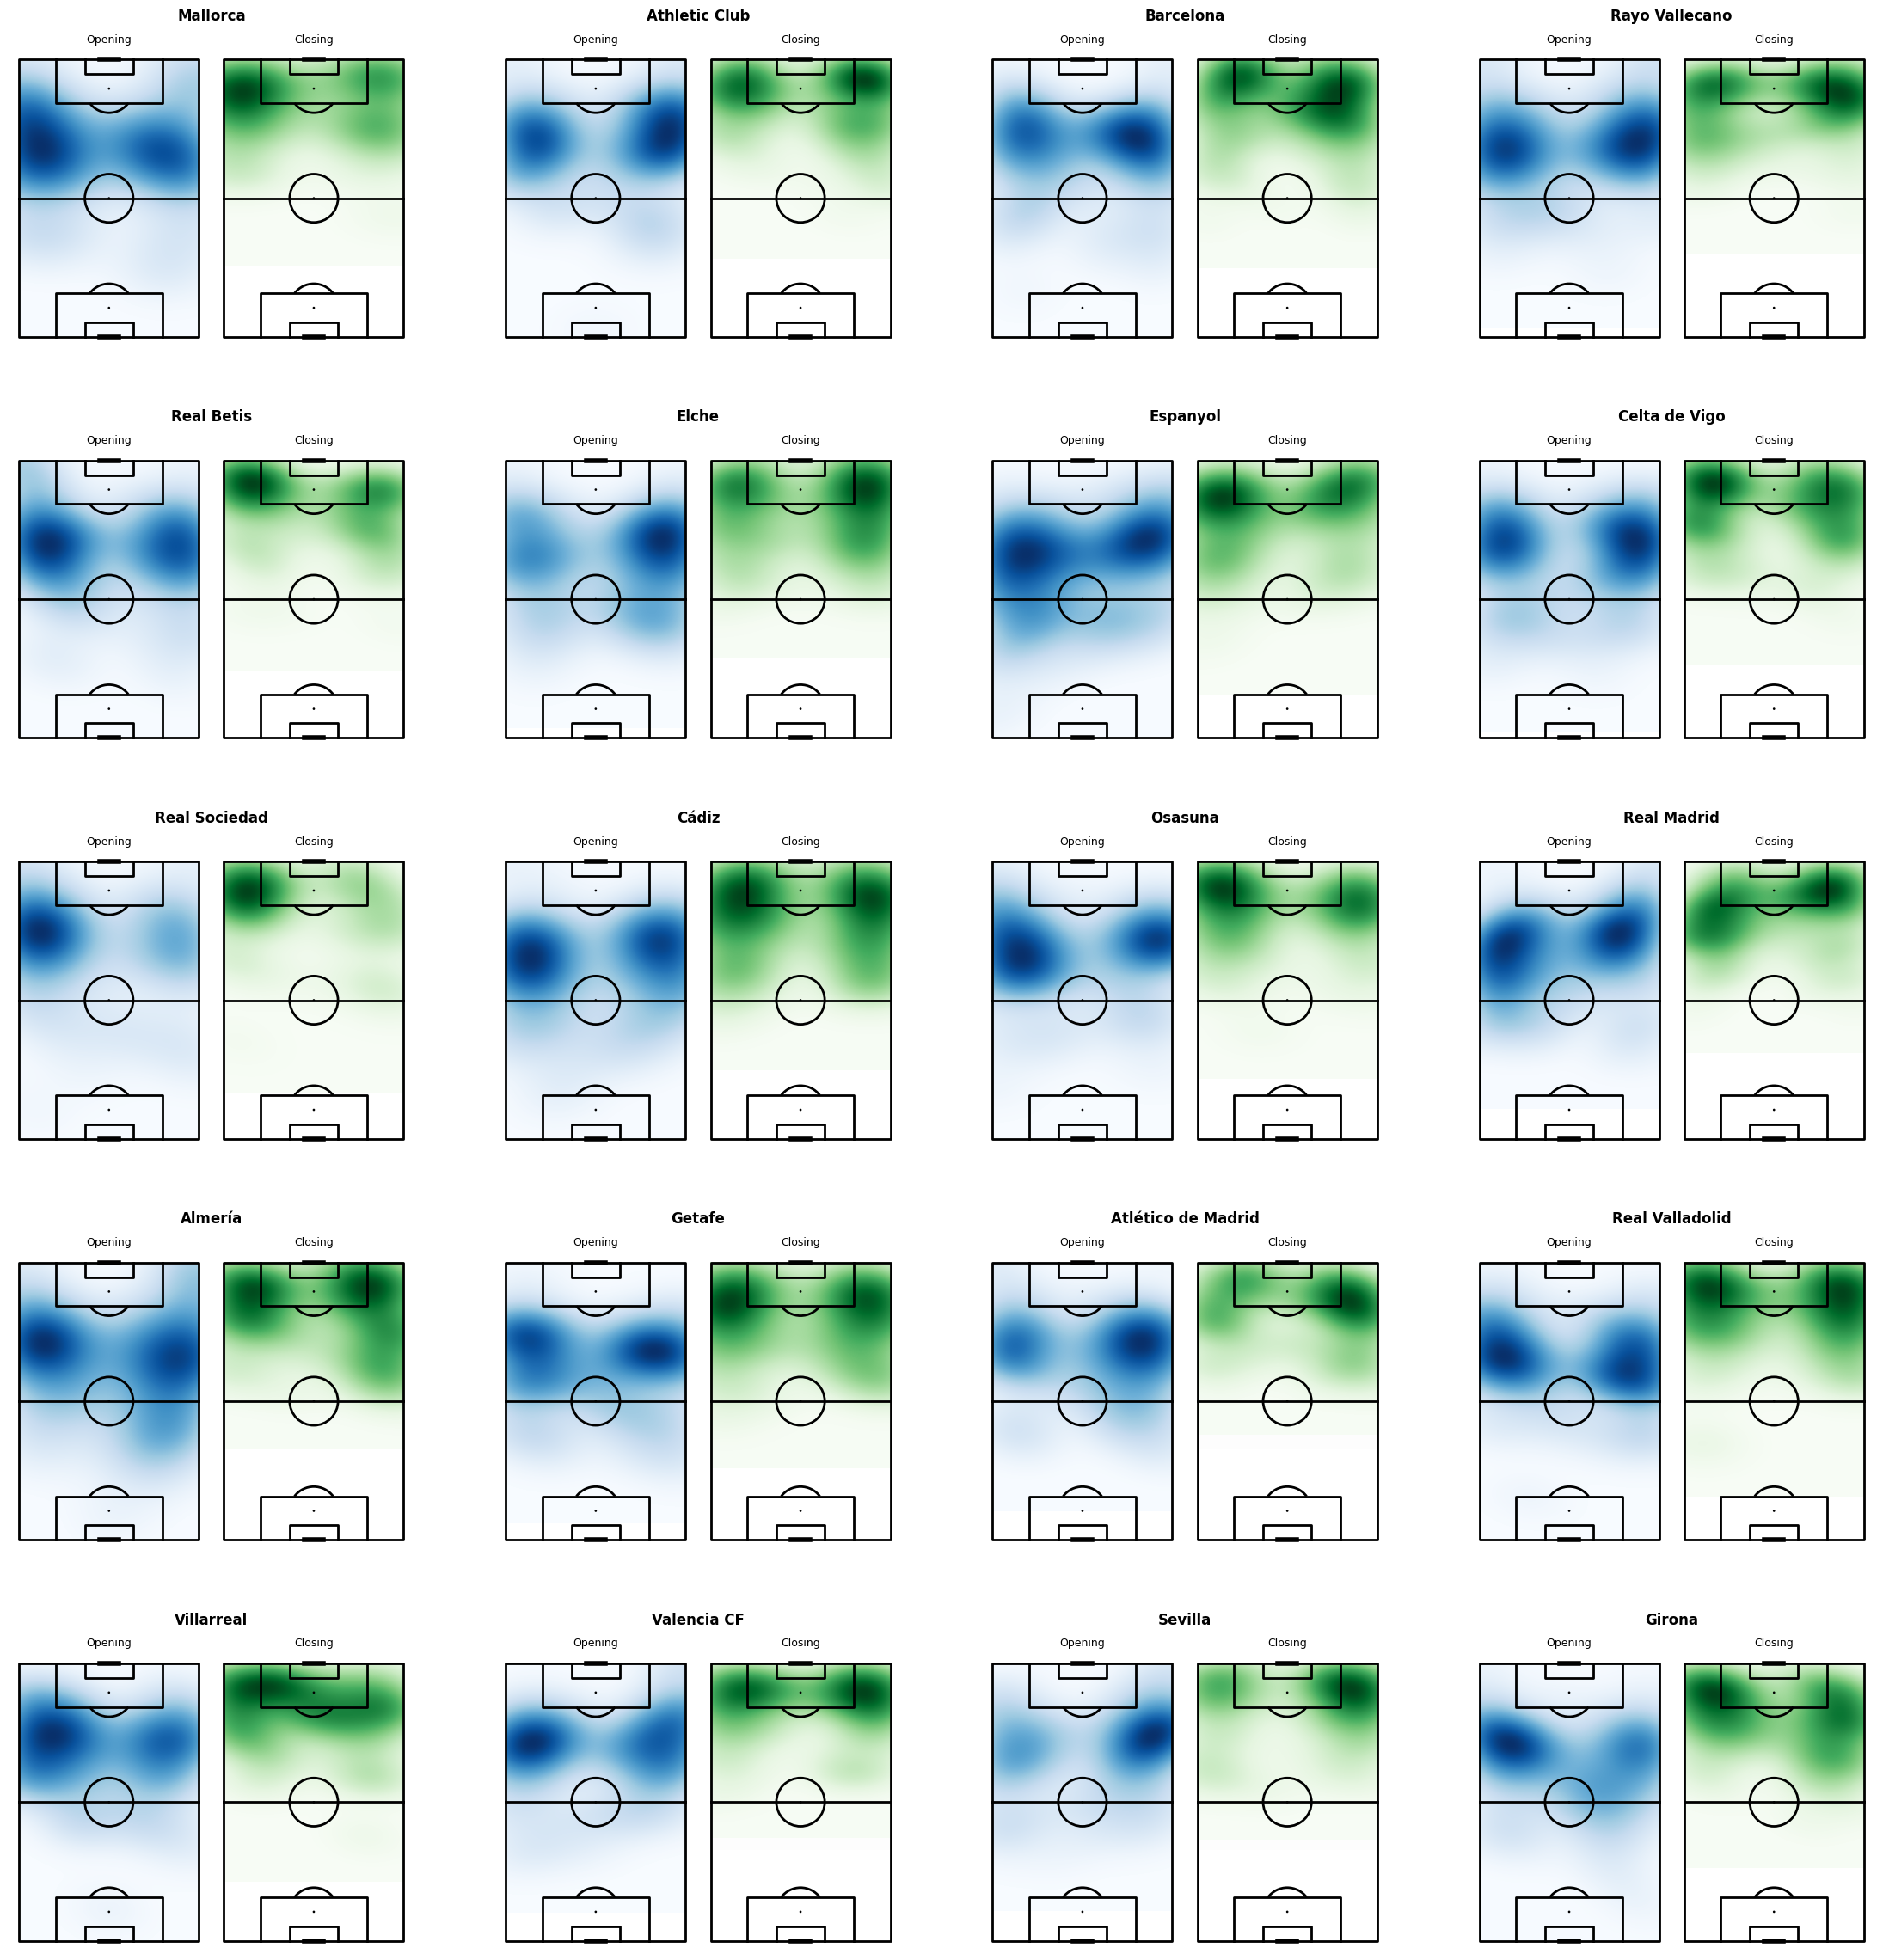

In [14]:
plot_one_twos_heatmap(progressive_one_twos_df, teams_per_row=4)

### One twos involvement (player level)

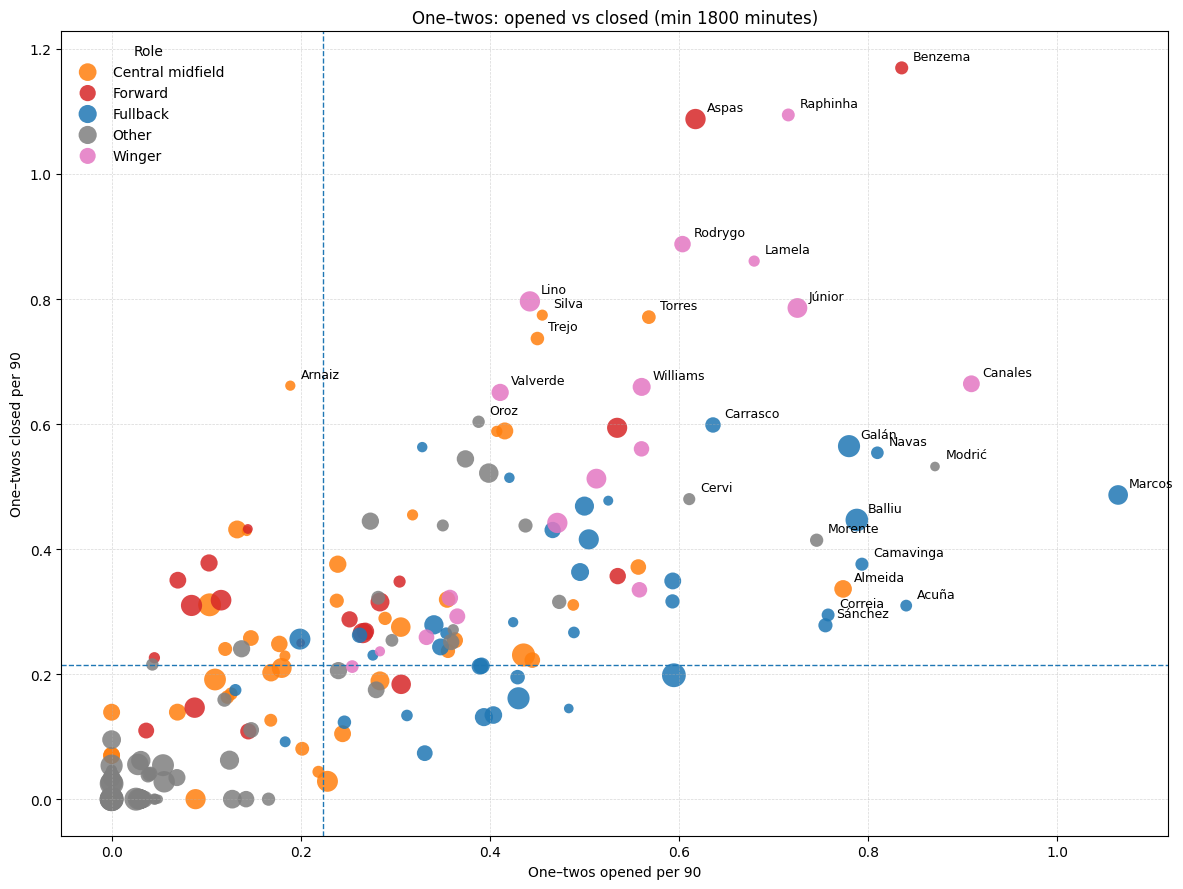

In [107]:
tbl = plot_onetwos_scatter_player(
    progressive_one_twos_df_, players_df, min_minutes=1800, label_thresh=0.6
)

### One twos duos (player level)
* (Minimum 300 common mins)

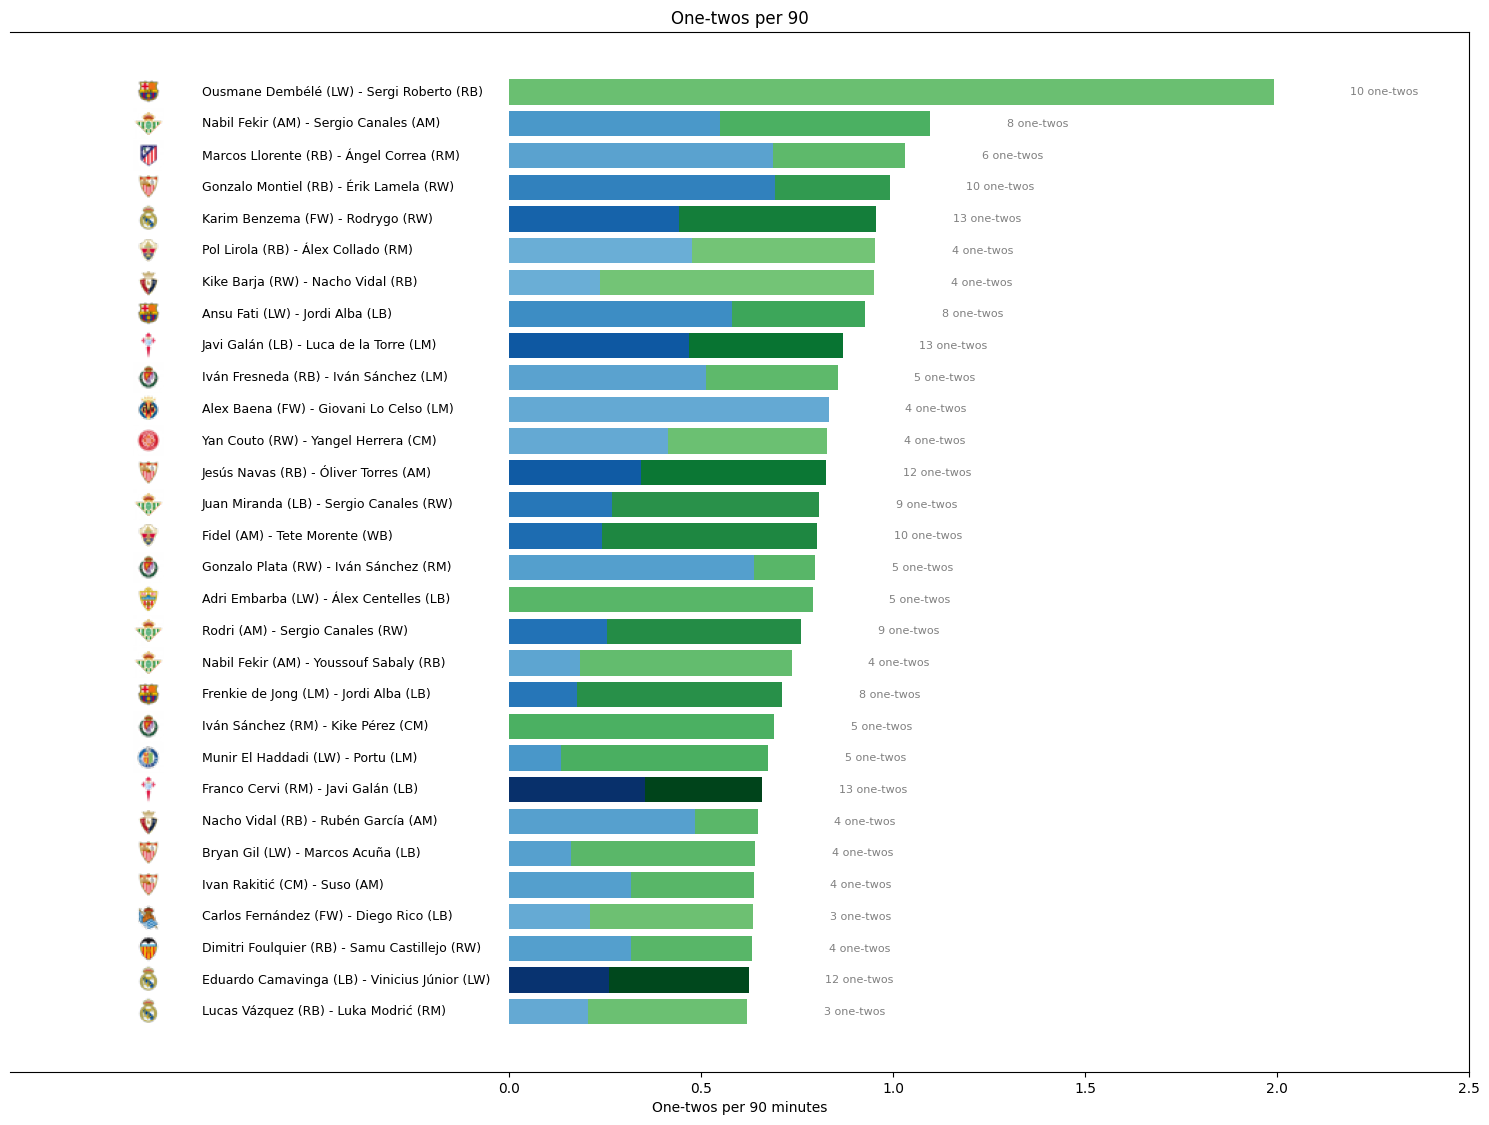

In [70]:
plot_one_twos_per_90(
    onetwos_pairs_df, progressive_one_twos_df_, 360, 30, logos_folder_path
)

### One twos and chance creation (team/competition level)

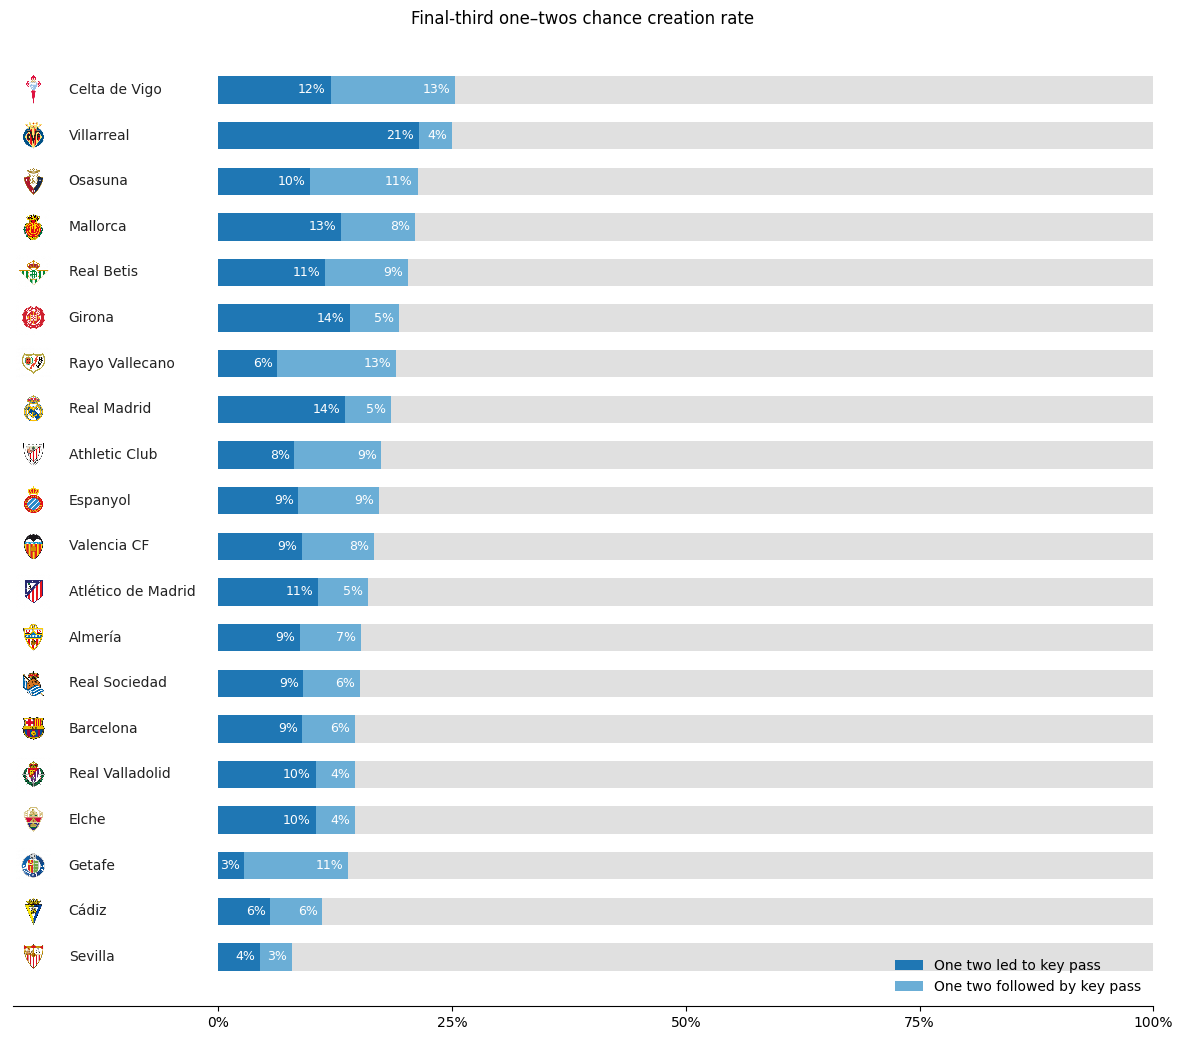

In [ ]:
one_twos_chance_creation_stats = plot_onetwos_chance_creation(
    progressive_one_twos_df_, x_thresh=70, logo_folder=logos_folder_path
)